In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import h5py
import joblib
import json
import warnings
from pathlib import Path
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.stats import wilcoxon

In [4]:
warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────
MULTI_OMICS_BASE = Path("/Users/bgadmin/Downloads/multiomics_preproc")
CNV_ONLY_BASE    = Path("/Users/bgadmin/Downloads/cnv_preproc_release_v2")
DOWNLOAD_DIR     = Path("/Users/bgadmin/Downloads/")
INFERENCE_DIR    = MULTI_OMICS_BASE / "inference_multiomics"
INFERENCE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR          = INFERENCE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── MOFA model ────────────────────────────────────────────────
MOFA_MODEL    = MULTI_OMICS_BASE / "mofa_model.hdf5"
MOFA_FACTORS  = MULTI_OMICS_BASE / "mofa_factors.parquet"

# ── Tumour cluster assignments ────────────────────────────────
CLUSTERS_DIR     = MULTI_OMICS_BASE / "clustering_leiden_A" / "clusters_by_group"
LEIDEN_MANIFEST  = MULTI_OMICS_BASE / "clustering_leiden_A" / "leiden_manifest_stats.tsv"

# ── Cell line data ────────────────────────────────────────────
CELL_LINES_TSV = Path("/Users/bgadmin/Downloads/cellline_analyses_global_with_cnv_panel.tsv")
BRIDGE_FILE    = DOWNLOAD_DIR / "bridge_progenetix_depmap.csv"
COVERAGE_FILE  = DOWNLOAD_DIR / "coverage_summary.csv"
RNA_FILE       = DOWNLOAD_DIR / "celllines_rna_mofa_features.parquet"
METH_FILE      = DOWNLOAD_DIR / "celllines_meth_mofa_features.parquet"

# ── CNV inference results (previous notebook) ─────────────────
CNV_PURITY_FILE = MULTI_OMICS_BASE / "inference" / "celllines_cluster_purity.parquet"

# ── Parameters ────────────────────────────────────────────────
K_NEIGHBORS = 50
N_FACTORS   = 20   # number of MOFA factors to use for kNN

print("Setup done.")

Setup done.


In [5]:
#  Load all data ─────────────────────────────────────────

# MOFA loadings and feature names
with h5py.File(MOFA_MODEL, "r") as f:
    features_rna  = [x.decode() for x in f["features/RNA"][:]]
    features_meth = [x.decode() for x in f["features/Meth"][:]]
    features_cnv  = [x.decode() for x in f["features/CNV"][:]]
    W_rna  = f["expectations/W/RNA"][:]
    W_meth = f["expectations/W/Meth"][:]
    W_cnv  = f["expectations/W/CNV"][:]

n_factors    = W_rna.shape[0]
factor_names = [f"Factor{i+1}" for i in range(n_factors)]

# Loading DataFrames: rows = features, cols = factors
df_W_rna  = pd.DataFrame(W_rna.T,  index=features_rna,  columns=factor_names)
df_W_meth = pd.DataFrame(W_meth.T, index=features_meth, columns=factor_names)
df_W_cnv  = pd.DataFrame(W_cnv.T,  index=features_cnv,  columns=factor_names)

print(f"MOFA factors     : {n_factors}")
print(f"RNA features     : {len(features_rna)}")
print(f"Meth features    : {len(features_meth)}")
print(f"CNV features     : {len(features_cnv)}")

# MOFA tumour factor scores (Z)
df_mofa_factors = pd.read_parquet(MOFA_FACTORS)
print(f"Tumour MOFA factors shape : {df_mofa_factors.shape}")

# Cell line omics data
df_rna  = pd.read_parquet(RNA_FILE)
df_meth = pd.read_parquet(METH_FILE)
print(f"Cell line RNA  shape : {df_rna.shape}")
print(f"Cell line Meth shape : {df_meth.shape}")

# Bridge and coverage
df_bridge   = pd.read_csv(BRIDGE_FILE)
df_coverage = pd.read_csv(COVERAGE_FILE)

# CNV data for cell lines
df_cl_cnv = pd.read_csv(CELL_LINES_TSV, sep="\t", low_memory=False)
cnv_cols  = [c for c in df_cl_cnv.columns
             if any(t in c for t in ["dup_frac", "del_frac",
                                      "hldup_frac", "hldel_frac"])]
print(f"CNV features     : {len(cnv_cols)}")

# Previous CNV-only purity results
df_cnv_purity = pd.read_parquet(CNV_PURITY_FILE)
print(f"CNV purity results : {df_cnv_purity.shape}")

# Tumour cluster assignments
import re
def cancer_group_to_filename(cancer_group):
    name = cancer_group.replace("/", "_").replace(" (", "_")
    name = name.replace(")", "").replace(" ", "_")
    name = re.sub(r"_+", "_", name)
    return f"{name}_clusters_leiden_cpm.parquet"

leiden_manifest = pd.read_csv(LEIDEN_MANIFEST, sep="\t")
cluster_frames  = []
for _, row in leiden_manifest.iterrows():
    fpath  = CLUSTERS_DIR / cancer_group_to_filename(row["cancer_group"])
    df_tmp = pd.read_parquet(fpath)
    df_tmp["cancer_group"] = row["cancer_group"]
    cluster_frames.append(df_tmp)

clusters_all = pd.concat(cluster_frames, ignore_index=True)
tumour_cluster_map = (
    clusters_all
    .drop_duplicates("biosample_id")
    .set_index("biosample_id")[["cancer_group", "cluster"]]
)
print(f"Tumour cluster map : {len(tumour_cluster_map)} tumours")
print("\nAll data loaded.")

MOFA factors     : 20
RNA features     : 1301
Meth features    : 1171
CNV features     : 5128
Tumour MOFA factors shape : (9592, 20)
Cell line RNA  shape : (1198, 1292)
Cell line Meth shape : (818, 982)
CNV features     : 4
CNV purity results : (3747, 9)
Tumour cluster map : 9582 tumours

All data loaded.


In [6]:
# ── [2] Build multi-omic feature matrix for cell lines ────────
# For each cell line, build a feature vector aligned with
# the MOFA model features (RNA + Meth + CNV)

print("Building multi-omic feature matrices...")

# ── 2.1 CNV matrix aligned to MOFA features ──────────────────
# MOFA CNV features: 'A1CF__dup_CNV' → map to 'cnv_A1CF__dup'
def mofa_cnv_to_depmap(mofa_feat):
    # 'A1CF__dup_CNV' → 'cnv_A1CF__dup_frac'
    base = mofa_feat.replace("_CNV", "")  # 'A1CF__dup'
    return f"cnv_{base}_frac"

cnv_col_map  = {f: mofa_cnv_to_depmap(f) for f in features_cnv}
available_cnv = {k: v for k, v in cnv_col_map.items() if v in df_cl_cnv.columns}
missing_cnv   = [k for k in cnv_col_map if cnv_col_map[k] not in df_cl_cnv.columns]
print(f"  CNV features found : {len(available_cnv)}/{len(features_cnv)}")
print(f"  CNV missing        : {len(missing_cnv)}")

# Build CNV matrix indexed by biosample_id
df_cl_cnv_matrix = (
    df_cl_cnv[["biosample_id"] + list(available_cnv.values())]
    .drop_duplicates("biosample_id")
    .set_index("biosample_id")
)
# Rename to MOFA feature names
reverse_map = {v: k for k, v in available_cnv.items()}
df_cl_cnv_matrix = df_cl_cnv_matrix.rename(columns=reverse_map)
print(f"  CNV matrix shape   : {df_cl_cnv_matrix.shape}")

# ── 2.2 RNA matrix — already aligned ─────────────────────────
# df_rna index = ModelID, columns = MOFA RNA feature names
# Need to map ModelID → biosample_id via bridge
model_to_biosample = (
    df_bridge[df_bridge["ModelID"].notna()]
    .drop_duplicates("ModelID")
    .set_index("ModelID")["biosample_id"]
    .to_dict()
)
df_rna_indexed = df_rna.copy()
df_rna_indexed.index = df_rna_indexed.index.map(model_to_biosample)
df_rna_indexed = df_rna_indexed[df_rna_indexed.index.notna()].copy()
print(f"  RNA matrix shape   : {df_rna_indexed.shape}")

# ── 2.3 Meth matrix — already aligned ────────────────────────
df_meth_indexed = df_meth.copy()
df_meth_indexed.index = df_meth_indexed.index.map(model_to_biosample)
df_meth_indexed = df_meth_indexed[df_meth_indexed.index.notna()].copy()
print(f"  Meth matrix shape  : {df_meth_indexed.shape}")

print("\nFeature matrices ready.")

Building multi-omic feature matrices...
  CNV features found : 0/5128
  CNV missing        : 5128
  CNV matrix shape   : (5752, 0)
  RNA matrix shape   : (1198, 1292)
  Meth matrix shape  : (818, 982)

Feature matrices ready.


In [7]:
# ── [3] Project cell lines into MOFA latent space ────────────
# MOFA computes Z = X @ W (approximately)
# More precisely: Z_i ≈ W^T * X_i (linear projection)
# We use the loadings W to project new samples

print("Projecting cell lines into MOFA latent space...")

def project_into_mofa(df_omic, df_W, omic_name):
    """
    Project cell line omic data into MOFA factor space.

    Parameters
    ----------
    df_omic : DataFrame (n_cells × n_features)
        Cell line omic data, columns = MOFA feature names
    df_W : DataFrame (n_features × n_factors)
        MOFA loadings matrix

    Returns
    -------
    DataFrame (n_cells × n_factors)
        Projected factor scores
    """
    # Align features — keep only features present in both
    common_features = df_omic.columns.intersection(df_W.index)
    X = df_omic[common_features].values.astype(np.float32)
    W = df_W.loc[common_features].values.astype(np.float32)

    # Fill NaN with 0 (mean imputation approximation)
    X = np.nan_to_num(X, nan=0.0)

    # Center X per feature (approximate MOFA preprocessing)
    X = X - np.nanmean(X, axis=0, keepdims=True)

    # Project: Z = X @ W  (n_cells × n_factors)
    Z = X @ W

    df_Z = pd.DataFrame(Z, index=df_omic.index, columns=factor_names)
    print(f"  {omic_name} projection : {df_Z.shape} "
          f"({len(common_features)}/{len(df_W)} features used)")
    return df_Z


# Project each omic separately
Z_rna  = project_into_mofa(df_rna_indexed,  df_W_rna,  "RNA")
Z_meth = project_into_mofa(df_meth_indexed, df_W_meth, "Meth")
Z_cnv  = project_into_mofa(df_cl_cnv_matrix, df_W_cnv, "CNV")

print("\nProjections done.")

Projecting cell lines into MOFA latent space...
  RNA projection : (1198, 20) (1292/1301 features used)
  Meth projection : (818, 20) (982/1171 features used)
  CNV projection : (5752, 20) (0/5128 features used)

Projections done.


In [9]:
# ── [4] Combine factor scores across omics ────────────────────
# Strategy: average the factor scores from each available omic
# weighted by number of features used

print("Combining MOFA factor scores across omics...")

def combine_factor_scores(biosample_id, Z_dict):
    """
    For a given cell line, combine factor scores from
    available omics by averaging.
    """
    scores = []
    for omic, Z in Z_dict.items():
        if biosample_id in Z.index:
            val = Z.loc[biosample_id]
            
            # If duplicate indices exist, val is a DataFrame; reduce it to a Series
            if isinstance(val, pd.DataFrame):
                val = val.mean(axis=0)
                
            scores.append(val.values)

    if not scores:
        return None

    return np.mean(scores, axis=0)


# Get all cell lines with at least RNA or Meth
all_cl_ids = set(Z_rna.index) | set(Z_meth.index)
print(f"Cell lines with RNA factors  : {len(Z_rna)}")
print(f"Cell lines with Meth factors : {len(Z_meth)}")
print(f"Cell lines with CNV factors  : {len(Z_cnv)}")
print(f"Total cell lines (RNA or Meth) : {len(all_cl_ids)}")

# Build combined factor matrix — RNA + Meth only
# (CNV is already used in the original inference notebook)
Z_dict_multiomics = {"RNA": Z_rna, "Meth": Z_meth}
Z_dict_all        = {"RNA": Z_rna, "Meth": Z_meth, "CNV": Z_cnv}

records_mo  = []
records_all = []

for bid in all_cl_ids:
    z_mo  = combine_factor_scores(bid, Z_dict_multiomics)
    z_all = combine_factor_scores(bid, Z_dict_all)
    if z_mo  is not None:
        records_mo.append( [bid] + z_mo.tolist())
    if z_all is not None:
        records_all.append([bid] + z_all.tolist())

df_Z_multiomics = pd.DataFrame(
    records_mo, columns=["biosample_id"] + factor_names
).set_index("biosample_id")

df_Z_all = pd.DataFrame(
    records_all, columns=["biosample_id"] + factor_names
).set_index("biosample_id")

print(f"\nCombined factor matrix (RNA + Meth)       : {df_Z_multiomics.shape}")
print(f"Combined factor matrix (RNA + Meth + CNV) : {df_Z_all.shape}")

# Save
df_Z_multiomics.to_parquet(INFERENCE_DIR / "celllines_mofa_factors_rna_meth.parquet")
df_Z_all.to_parquet(INFERENCE_DIR / "celllines_mofa_factors_all.parquet")
print("Saved factor matrices.")

Combining MOFA factor scores across omics...
Cell lines with RNA factors  : 1198
Cell lines with Meth factors : 818
Cell lines with CNV factors  : 5752
Total cell lines (RNA or Meth) : 1085

Combined factor matrix (RNA + Meth)       : (1085, 20)
Combined factor matrix (RNA + Meth + CNV) : (1085, 20)
Saved factor matrices.


In [10]:
# ── [5] kNN in MOFA space ─────────────────────────────────────
print("Running kNN in MOFA space...")

def run_knn_mofa(df_cl_factors, df_tumour_factors,
                 tumour_cluster_map, k=50, label=""):
    """
    For each cell line, find K nearest tumours in MOFA space
    and compute cluster purity.

    Parameters
    ----------
    df_cl_factors     : DataFrame (n_cells × n_factors)
    df_tumour_factors : DataFrame (n_tumours × n_factors)
    tumour_cluster_map: DataFrame with cancer_group and cluster

    Returns
    -------
    DataFrame with purity scores per cell line
    """
    # Align factors
    common_factors = df_cl_factors.columns.intersection(
        df_tumour_factors.columns
    )
    X_cl     = df_cl_factors[common_factors].values.astype(np.float32)
    X_tumour = df_tumour_factors[common_factors].values.astype(np.float32)
    cl_ids   = df_cl_factors.index.tolist()
    t_ids    = df_tumour_factors.index.tolist()

    if len(t_ids) < k:
        print(f"  {label} : not enough tumours ({len(t_ids)} < {k})")
        return pd.DataFrame()

    # Fit kNN on tumours
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(X_tumour)
    dists, idx = nn.kneighbors(X_cl)

    # Compute purity per cell line
    records = []
    for i, bid in enumerate(cl_ids):
        neighbour_ids = [t_ids[j] for j in idx[i]]

        # Get cluster assignments for neighbours
        neighbour_clusters = []
        for nid in neighbour_ids:
            if nid in tumour_cluster_map.index:
                cl_info = tumour_cluster_map.loc[nid]
                neighbour_clusters.append(
                    (cl_info["cancer_group"], cl_info["cluster"])
                )

        if not neighbour_clusters:
            continue

        cluster_counts = pd.Series(neighbour_clusters).value_counts()
        dominant       = cluster_counts.idxmax()
        purity         = cluster_counts.max() / len(neighbour_clusters)

        records.append({
            "biosample_id":         bid,
            "dominant_cluster":     int(dominant[1]),
            "dominant_cancer_group": dominant[0],
            "cluster_purity":       float(purity),
            "n_neighbours_annotated": len(neighbour_clusters),
            "mean_distance":        float(dists[i].mean()),
        })

    df_purity = pd.DataFrame(records)
    print(f"  {label} : {len(df_purity)} cell lines processed, "
          f"median purity = {df_purity['cluster_purity'].median():.3f}")
    return df_purity


# Run kNN for RNA + Meth projection
df_purity_mo = run_knn_mofa(
    df_Z_multiomics,
    df_mofa_factors,
    tumour_cluster_map,
    k=K_NEIGHBORS,
    label="RNA + Meth"
)

# Run kNN for RNA + Meth + CNV projection
df_purity_all = run_knn_mofa(
    df_Z_all,
    df_mofa_factors,
    tumour_cluster_map,
    k=K_NEIGHBORS,
    label="RNA + Meth + CNV"
)

# Save
df_purity_mo.to_parquet(
    INFERENCE_DIR / "purity_rna_meth.parquet"
)
df_purity_all.to_parquet(
    INFERENCE_DIR / "purity_rna_meth_cnv.parquet"
)
print("\nkNN done.")

Running kNN in MOFA space...
  RNA + Meth : 1085 cell lines processed, median purity = 0.480
  RNA + Meth + CNV : 1085 cell lines processed, median purity = 0.460

kNN done.


In [11]:
# ── [6] Compare CNV-only vs multi-omic purity ─────────────────
print("Comparing CNV-only vs multi-omic purity...")

# Load CNV-only purity from previous notebook
df_cnv_purity_clean = (
    df_cnv_purity[["cl_biosample_id", "cluster_purity",
                   "dominant_cluster", "icdot_root"]]
    .rename(columns={
        "cl_biosample_id": "biosample_id",
        "cluster_purity":  "purity_cnv",
    })
)

# Merge with multi-omic purity
df_compare = df_cnv_purity_clean.merge(
    df_purity_mo[["biosample_id", "cluster_purity"]]
    .rename(columns={"cluster_purity": "purity_rna_meth"}),
    on="biosample_id", how="inner"
).merge(
    df_purity_all[["biosample_id", "cluster_purity"]]
    .rename(columns={"cluster_purity": "purity_rna_meth_cnv"}),
    on="biosample_id", how="inner"
)

print(f"Cell lines in comparison : {len(df_compare)}")
print(f"\nMedian purity by approach :")
print(f"  CNV only          : {df_compare['purity_cnv'].median():.3f}")
print(f"  RNA + Meth        : {df_compare['purity_rna_meth'].median():.3f}")
print(f"  RNA + Meth + CNV  : {df_compare['purity_rna_meth_cnv'].median():.3f}")

# Statistical test — Wilcoxon signed-rank
stat, p_cnv_vs_mo = wilcoxon(
    df_compare["purity_cnv"],
    df_compare["purity_rna_meth"]
)
print(f"\nWilcoxon CNV vs RNA+Meth : p = {p_cnv_vs_mo:.2e}")

# Save comparison
df_compare.to_csv(INFERENCE_DIR / "purity_comparison.tsv",
                  sep="\t", index=False)
print("Saved: purity_comparison.tsv")

Comparing CNV-only vs multi-omic purity...
Cell lines in comparison : 675

Median purity by approach :
  CNV only          : 0.660
  RNA + Meth        : 0.480
  RNA + Meth + CNV  : 0.460

Wilcoxon CNV vs RNA+Meth : p = 1.58e-48
Saved: purity_comparison.tsv


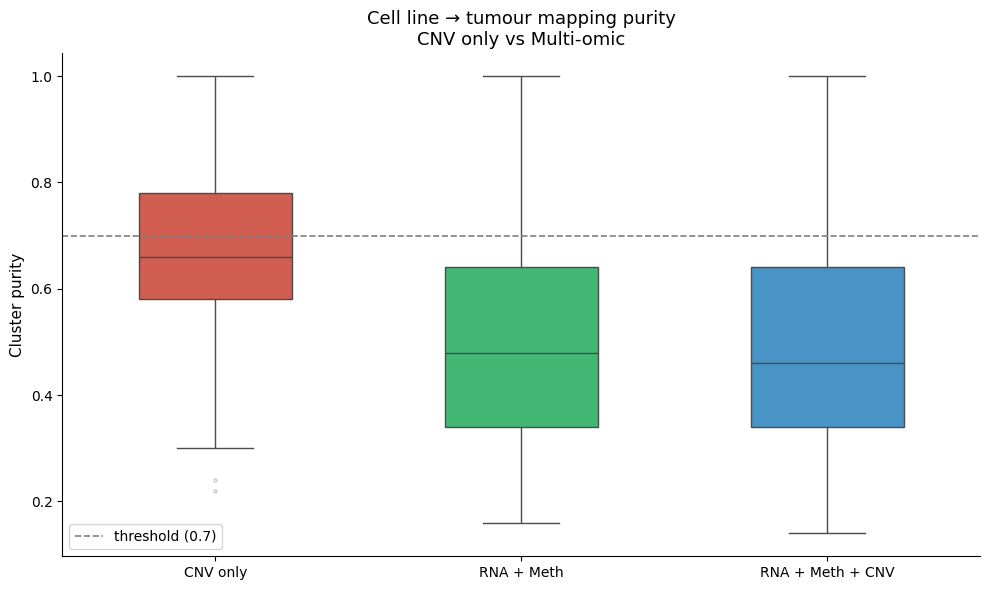

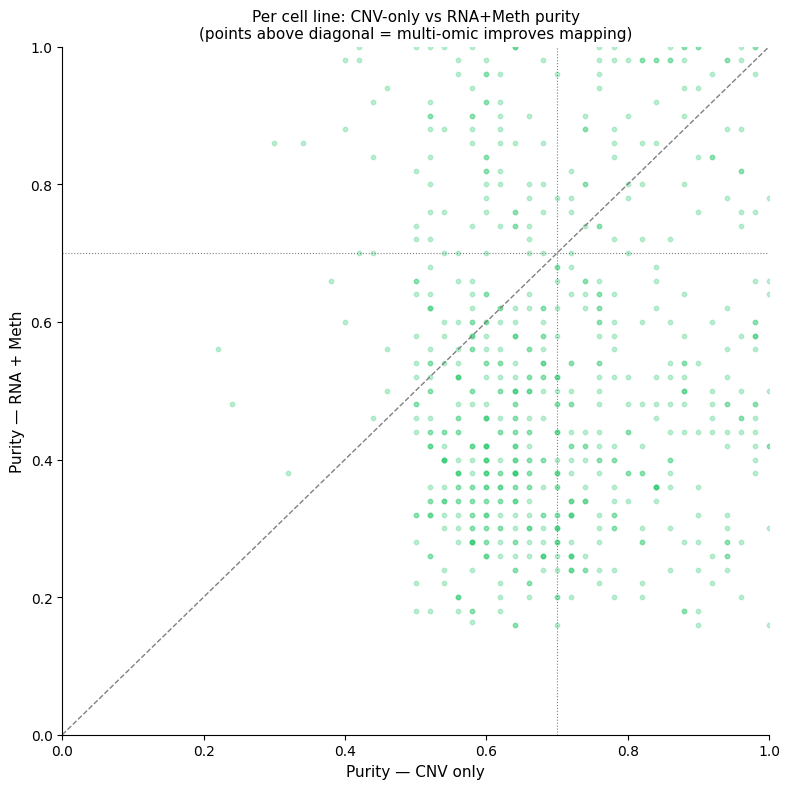

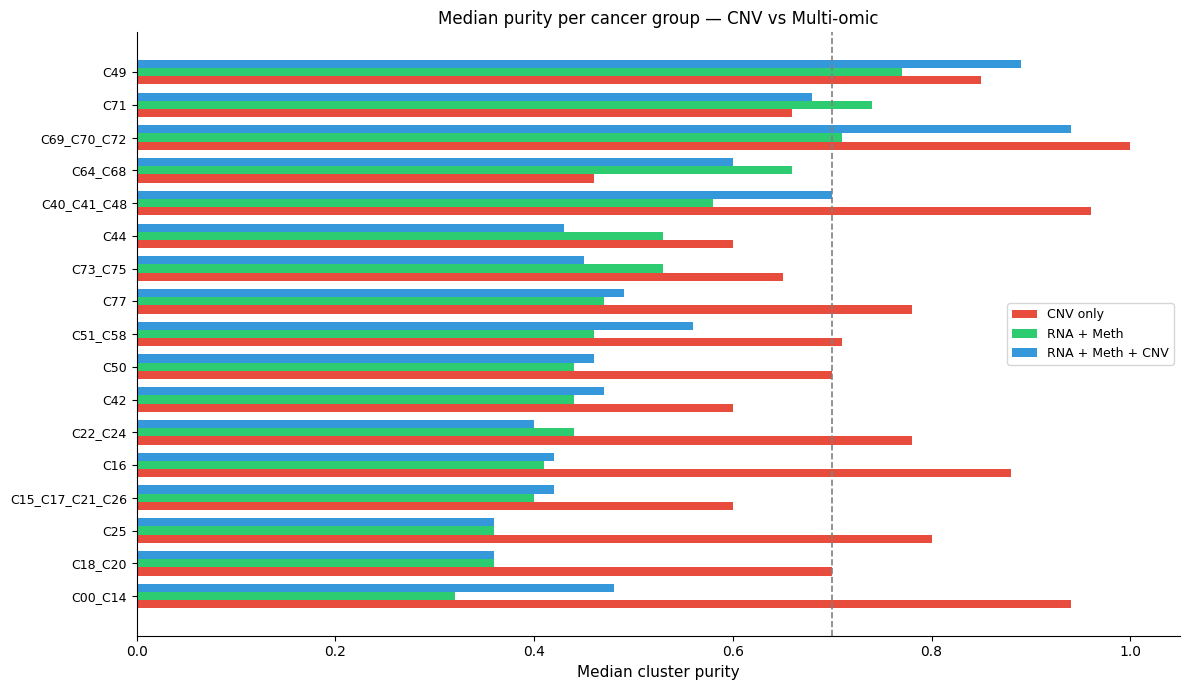

All figures saved.


In [12]:
# ── [7] Figures ───────────────────────────────────────────────

# Fig 1 — Boxplot: purity distribution per approach
fig, ax = plt.subplots(figsize=(10, 6))

data_plot = pd.DataFrame({
    "CNV only":         df_compare["purity_cnv"].values,
    "RNA + Meth":       df_compare["purity_rna_meth"].values,
    "RNA + Meth + CNV": df_compare["purity_rna_meth_cnv"].values,
})

sns.boxplot(data=data_plot, palette=["#e74c3c", "#2ecc71", "#3498db"],
            width=0.5, ax=ax,
            flierprops=dict(marker="o", markersize=2, alpha=0.3))

ax.axhline(0.7, color="gray", linestyle="--", linewidth=1.2,
           label="threshold (0.7)")
ax.set_ylabel("Cluster purity", fontsize=11)
ax.set_title("Cell line → tumour mapping purity\nCNV only vs Multi-omic",
             fontsize=13)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_purity_comparison_boxplot.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Fig 2 — Scatter: CNV purity vs RNA+Meth purity per cell line
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df_compare["purity_cnv"],
           df_compare["purity_rna_meth"],
           alpha=0.3, s=10, color="#2ecc71")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
ax.axhline(0.7, color="gray", linestyle=":", linewidth=0.8)
ax.axvline(0.7, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("Purity — CNV only", fontsize=11)
ax.set_ylabel("Purity — RNA + Meth", fontsize=11)
ax.set_title("Per cell line: CNV-only vs RNA+Meth purity\n"
             "(points above diagonal = multi-omic improves mapping)",
             fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_purity_scatter_cnv_vs_multiomics.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Fig 3 — Per cancer group: median purity CNV vs RNA+Meth
group_compare = (
    df_compare
    .groupby("icdot_root")[["purity_cnv", "purity_rna_meth",
                             "purity_rna_meth_cnv"]]
    .median()
    .sort_values("purity_rna_meth", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 7))
x      = range(len(group_compare))
width  = 0.25

ax.barh([i - width for i in x], group_compare["purity_cnv"],
        height=width, color="#e74c3c", label="CNV only")
ax.barh(x, group_compare["purity_rna_meth"],
        height=width, color="#2ecc71", label="RNA + Meth")
ax.barh([i + width for i in x], group_compare["purity_rna_meth_cnv"],
        height=width, color="#3498db", label="RNA + Meth + CNV")

ax.set_yticks(list(x))
ax.set_yticklabels(group_compare.index, fontsize=9)
ax.axvline(0.7, color="gray", linestyle="--", linewidth=1.2)
ax.set_xlabel("Median cluster purity", fontsize=11)
ax.set_title("Median purity per cancer group — CNV vs Multi-omic",
             fontsize=12)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_purity_per_group_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("All figures saved.")

In [13]:
# ── Check mofapy2 capabilities ────────────────────────────────
import mofapy2
from mofapy2.run.entry_point import entry_point
print(f"mofapy2 version : {mofapy2.__version__}")

# Check available methods
print(dir(entry_point))

mofapy2 version : 0.7.4
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'build', 'impute', 'mask_outliers', 'predict_factor', 'print_banner', 'run', 'save', 'set_covariates', 'set_data_df', 'set_data_from_anndata', 'set_data_from_loom', 'set_data_matrix', 'set_data_options', 'set_model_options', 'set_smooth_options', 'set_stochastic_options', 'set_train_options']


In [19]:
# ── Pivot cell line CNV from long to wide format ──────────────
print("Pivoting cell line CNV from long to wide format...")
print(f"Raw shape : {df_cl_cnv.shape}")
print(f"Columns   : {df_cl_cnv.columns.tolist()[:10]}")
print(df_cl_cnv.head(3)[["biosample_id", "gene_symbol",
                           "dup_frac", "del_frac",
                           "hldup_frac", "hldel_frac"]])

# ── Build wide CNV matrix ─────────────────────────────────────
# Keep only genes present in MOFA CNV features
mofa_cnv_genes = set(f.replace("__dup_CNV", "")
                      .replace("__del_CNV", "")
                      .replace("__hldup_CNV", "")
                      .replace("__hldel_CNV", "")
                     for f in features_cnv)

print(f"MOFA CNV unique genes : {len(mofa_cnv_genes)}")

# Filter to MOFA genes only before pivoting (much faster)
df_cl_cnv_filt = df_cl_cnv[
    df_cl_cnv["gene_symbol"].isin(mofa_cnv_genes)
][["biosample_id", "gene_symbol",
   "dup_frac", "del_frac",
   "hldup_frac", "hldel_frac"]].copy()

print(f"Filtered rows : {df_cl_cnv_filt.shape}")

# Create one column per gene × type
# 'dup_frac' for gene 'A1CF' → 'A1CF__dup_CNV'
df_cl_cnv_filt["feat_dup"]   = df_cl_cnv_filt["gene_symbol"] + "__dup_CNV"
df_cl_cnv_filt["feat_del"]   = df_cl_cnv_filt["gene_symbol"] + "__del_CNV"
df_cl_cnv_filt["feat_hldup"] = df_cl_cnv_filt["gene_symbol"] + "__hldup_CNV"
df_cl_cnv_filt["feat_hldel"] = df_cl_cnv_filt["gene_symbol"] + "__hldel_CNV"

# Pivot dup
print("Pivoting dup...")
df_dup = df_cl_cnv_filt.pivot_table(
    index="biosample_id", columns="feat_dup",
    values="dup_frac", aggfunc="first"
)

# Pivot del
print("Pivoting del...")
df_del = df_cl_cnv_filt.pivot_table(
    index="biosample_id", columns="feat_del",
    values="del_frac", aggfunc="first"
)

# Pivot hldup
print("Pivoting hldup...")
df_hldup = df_cl_cnv_filt.pivot_table(
    index="biosample_id", columns="feat_hldup",
    values="hldup_frac", aggfunc="first"
)

# Pivot hldel
print("Pivoting hldel...")
df_hldel = df_cl_cnv_filt.pivot_table(
    index="biosample_id", columns="feat_hldel",
    values="hldel_frac", aggfunc="first"
)

# Concatenate all types
df_cl_cnv_wide = pd.concat([df_dup, df_del, df_hldup, df_hldel], axis=1)
df_cl_cnv_wide.columns.name = None

print(f"\nWide CNV matrix shape : {df_cl_cnv_wide.shape}")

# Check overlap with MOFA features
common_cnv = df_cl_cnv_wide.columns.intersection(features_cnv)
print(f"Common with MOFA CNV features : {len(common_cnv)}/{len(features_cnv)}")
print(f"Sample common : {common_cnv[:5].tolist()}")

# Save
df_cl_cnv_wide.to_parquet(
    DOWNLOAD_DIR / "celllines_cnv_wide.parquet"
)
print("Saved: celllines_cnv_wide.parquet")

Pivoting cell line CNV from long to wide format...
Raw shape : (7500608, 18)
Columns   : ['analysis_id', 'gene_symbol', 'gene_id', 'chrom', 'start', 'end', 'dup_frac', 'del_frac', 'hldup_frac', 'hldel_frac']
     biosample_id gene_symbol  dup_frac  del_frac  hldup_frac  hldel_frac
0  pgxbs-kftvi9xs        NADK       0.0       0.0         0.0         0.0
1  pgxbs-kftvi9xs        GNB1       0.0       0.0         0.0         0.0
2  pgxbs-kftvi9xs         SKI       0.0       0.0         0.0         0.0
MOFA CNV unique genes : 1297
Filtered rows : (7460344, 6)
Pivoting dup...
Pivoting del...
Pivoting hldup...
Pivoting hldel...

Wide CNV matrix shape : (5752, 5188)
Common with MOFA CNV features : 5128/5128
Sample common : ['A1CF__dup_CNV', 'ABCB1__dup_CNV', 'ABCC3__dup_CNV', 'ABI1__dup_CNV', 'ABL1__dup_CNV']
Saved: celllines_cnv_wide.parquet


In [22]:
# ── Debug Meth NaN issue ──────────────────────────────────────
print("Meth matrix info :")
print(f"  Shape  : {df_meth_indexed.shape}")
print(f"  NaN    : {df_meth_indexed.isna().sum().sum()}")
print(f"  Non-NaN: {df_meth_indexed.notna().sum().sum()}")
print(f"  Sample values :")
print(df_meth_indexed.iloc[:3, :5])

# Check if values exist at all
print(f"\nMeth raw file check :")
meth_path = DOWNLOAD_DIR / "ccle_multiomics/CCLE_RRBS_TSS_1kb_20180614.txt"
df_meth_check = pd.read_csv(meth_path, sep="\t", nrows=5)
print(df_meth_check.iloc[:, :10])

Meth matrix info :
  Shape  : (818, 982)
  NaN    : 21370
  Non-NaN: 781906
  Sample values :
                ABCC3_Meth  ABL1_Meth  ABL2_Meth  ACSL3_Meth  ACSL6_Meth
ModelID                                                                 
pgxbs-kftviek4     0.30476   0.003315    0.00096         0.0    0.002477
pgxbs-kftvitf5     0.29747   0.002230    0.00000         0.0    0.037723
pgxbs-kftvkt4a     0.85351   0.053865    0.06884         0.0    0.891910

Meth raw file check :
                         TSS_id          gene   chr    fpos    tpos strand  \
0  LOC100288069_1_714068_715068  LOC100288069  chr1  714068  715068      -   
1     LINC01128_1_761970_762970     LINC01128  chr1  761970  762970      +   
2     LINC01128_1_762177_763177     LINC01128  chr1  762177  763177      +   
3  LOC100130417_1_855072_856072  LOC100130417  chr1  855072  856072      -   
4        SAMD11_1_860120_861120        SAMD11  chr1  860120  861120      +   

   avg_coverage  DMS53_LUNG  SW1116_LARGE_INTESTI

In [26]:
with h5py.File(MOFA_MODEL, "r") as f:
    meth_mofa_data     = f["data/Meth/all_samples"][:]
    meth_feature_names = [x.decode() for x in f["features/Meth"][:]]
    sample_ids         = [x.decode() for x in f["samples/all_samples"][:]]

print(f"meth_mofa_data shape : {meth_mofa_data.shape}")
# (9592, 1171) → rows=samples, cols=features — no transpose needed

df_meth_tumour = pd.DataFrame(
    meth_mofa_data,
    index=sample_ids,
    columns=meth_feature_names
)

print(f"df_meth_tumour shape : {df_meth_tumour.shape}")
print(f"Range  : [{np.nanmin(df_meth_tumour.values):.3f}, "
      f"{np.nanmax(df_meth_tumour.values):.3f}]")
print(f"Mean   : {np.nanmean(df_meth_tumour.values):.6f}")
print(f"\nPer-feature mean (first 5) :")
print(df_meth_tumour.iloc[:, :5].mean())
print(f"\nPer-feature std (first 5) :")
print(df_meth_tumour.iloc[:, :5].std())
print(f"\nIntercepts Meth (first 5) :")
print(intercepts_meth[:5])
print(f"\nCell line Meth (first 5 features, first 3 rows) :")
print(df_meth_indexed.iloc[:3, :5])

meth_mofa_data shape : (9592, 1171)
df_meth_tumour shape : (9592, 1171)
Range  : [-5.174, 5.185]
Mean   : -0.000000

Per-feature mean (first 5) :
ARID4B_Meth   -8.148426e-18
PICALM_Meth    7.259507e-17
EPCAM_Meth     4.370519e-17
ERG_Meth      -5.926128e-18
FOXR1_Meth    -5.926128e-17
dtype: float64

Per-feature std (first 5) :
ARID4B_Meth    0.997688
PICALM_Meth    0.996318
EPCAM_Meth     0.997178
ERG_Meth       0.996476
FOXR1_Meth     0.994727
dtype: float64

Intercepts Meth (first 5) :
[-3.77870247e-04 -7.07936643e-05 -8.18780171e-05  1.37878658e-05
  1.48283728e-05]

Cell line Meth (first 5 features, first 3 rows) :
                ABCC3_Meth  ABL1_Meth  ABL2_Meth  ACSL3_Meth  ACSL6_Meth
ModelID                                                                 
pgxbs-kftviek4     0.30476   0.003315    0.00096         0.0    0.002477
pgxbs-kftvitf5     0.29747   0.002230    0.00000         0.0    0.037723
pgxbs-kftvkt4a     0.85351   0.053865    0.06884         0.0    0.891910


In [20]:
# ── Check RNA and Meth scale vs MOFA tumour data ──────────────
with h5py.File(MOFA_MODEL, "r") as f:
    rna_tumour  = f["data/RNA/all_samples"][:]
    meth_tumour = f["data/Meth/all_samples"][:]
    cnv_tumour  = f["data/CNV/all_samples"][:]

print("Tumour data ranges (as stored in MOFA) :")
print(f"  RNA  : [{np.nanmin(rna_tumour):.3f},  {np.nanmax(rna_tumour):.3f}]  "
      f"mean={np.nanmean(rna_tumour):.3f}")
print(f"  Meth : [{np.nanmin(meth_tumour):.3f}, {np.nanmax(meth_tumour):.3f}]  "
      f"mean={np.nanmean(meth_tumour):.3f}")
print(f"  CNV  : [{np.nanmin(cnv_tumour):.3f},  {np.nanmax(cnv_tumour):.3f}]  "
      f"mean={np.nanmean(cnv_tumour):.3f}")

print("\nCell line data ranges :")
print(f"  RNA  : [{df_rna_indexed.values.min():.3f},  "
      f"{df_rna_indexed.values.max():.3f}]  "
      f"mean={df_rna_indexed.values.mean():.3f}")
print(f"  Meth : [{df_meth_indexed.values.min():.3f}, "
      f"{df_meth_indexed.values.max():.3f}]  "
      f"mean={np.nanmean(df_meth_indexed.values):.3f}")
print(f"  CNV  : [{df_cl_cnv_wide.values.min():.3f},  "
      f"{df_cl_cnv_wide.values.max():.3f}]  "
      f"mean={np.nanmean(df_cl_cnv_wide.values):.3f}")

Tumour data ranges (as stored in MOFA) :
  RNA  : [-5.410,  218.639]  mean=-0.000
  Meth : [-5.174, 5.185]  mean=-0.000
  CNV  : [-0.709,  97.934]  mean=-0.000

Cell line data ranges :
  RNA  : [0.000,  15.247]  mean=3.488
  Meth : [nan, nan]  mean=0.138
  CNV  : [0.000,  2.000]  mean=0.086


In [27]:
# ── Compute tumour statistics for standardization ─────────────
print("Computing tumour statistics for standardization...")

with h5py.File(MOFA_MODEL, "r") as f:
    rna_mofa_data  = f["data/RNA/all_samples"][:]
    meth_mofa_data = f["data/Meth/all_samples"][:]
    cnv_mofa_data  = f["data/CNV/all_samples"][:]
    rna_features   = [x.decode() for x in f["features/RNA"][:]]
    meth_features  = [x.decode() for x in f["features/Meth"][:]]
    cnv_features   = [x.decode() for x in f["features/CNV"][:]]

# Compute per-feature mean and std from tumour data
# These are the parameters we need to apply to cell lines
tumour_rna_mean  = np.nanmean(rna_mofa_data,  axis=0)
tumour_rna_std   = np.nanstd(rna_mofa_data,   axis=0)
tumour_meth_mean = np.nanmean(meth_mofa_data, axis=0)
tumour_meth_std  = np.nanstd(meth_mofa_data,  axis=0)
tumour_cnv_mean  = np.nanmean(cnv_mofa_data,  axis=0)
tumour_cnv_std   = np.nanstd(cnv_mofa_data,   axis=0)

# Replace 0 std with 1 to avoid division by zero
tumour_rna_std[tumour_rna_std   == 0] = 1.0
tumour_meth_std[tumour_meth_std == 0] = 1.0
tumour_cnv_std[tumour_cnv_std   == 0] = 1.0

print(f"RNA  : mean range [{tumour_rna_mean.min():.3f}, "
      f"{tumour_rna_mean.max():.3f}], "
      f"std range [{tumour_rna_std.min():.3f}, "
      f"{tumour_rna_std.max():.3f}]")
print(f"Meth : mean range [{tumour_meth_mean.min():.3f}, "
      f"{tumour_meth_mean.max():.3f}], "
      f"std range [{tumour_meth_std.min():.3f}, "
      f"{tumour_meth_std.max():.3f}]")
print(f"CNV  : mean range [{tumour_cnv_mean.min():.3f}, "
      f"{tumour_cnv_mean.max():.3f}], "
      f"std range [{tumour_cnv_std.min():.3f}, "
      f"{tumour_cnv_std.max():.3f}]")

Computing tumour statistics for standardization...
RNA  : mean range [-0.000, 0.000], std range [0.043, 17.820]
Meth : mean range [-0.000, 0.000], std range [0.995, 1.040]
CNV  : mean range [-0.000, 0.000], std range [1.000, 1.000]


In [28]:
# ── Standardize cell line data using tumour statistics ─────────
print("Standardizing cell line data using tumour statistics...")

def standardize_celllines(df_omic, feature_names,
                           tumour_mean, tumour_std, omic_name):
    """
    Standardize cell line omic data using tumour mean and std.
    For missing features, impute with 0 (= tumour mean after standardization).
    """
    # Align features — keep only features present in MOFA
    mofa_features   = pd.Index(feature_names)
    common_features = df_omic.columns.intersection(mofa_features)
    missing_features = mofa_features.difference(df_omic.columns)

    print(f"  {omic_name}: {len(common_features)} present, "
          f"{len(missing_features)} missing (will be imputed with 0)")

    # Get indices of common features in MOFA feature list
    feat_idx = [list(feature_names).index(f) for f in common_features]

    # Extract values and standardize
    X         = df_omic[common_features].values.astype(np.float32)
    mean_vec  = tumour_mean[feat_idx].astype(np.float32)
    std_vec   = tumour_std[feat_idx].astype(np.float32)

    # Impute NaN with feature mean (before standardization)
    nan_mask  = np.isnan(X)
    for j in range(X.shape[1]):
        X[nan_mask[:, j], j] = mean_vec[j]

    # Standardize: (X - mean) / std
    X_std = (X - mean_vec) / std_vec

    # Build full matrix with all MOFA features
    # Missing features = 0 (tumour mean after standardization)
    X_full = np.zeros(
        (len(df_omic), len(feature_names)), dtype=np.float32
    )
    for i, feat in enumerate(common_features):
        j = list(feature_names).index(feat)
        X_full[:, j] = X_std[:, i]

    df_std = pd.DataFrame(
        X_full,
        index=df_omic.index,
        columns=feature_names
    )

    print(f"  {omic_name} standardized range : "
          f"[{X_full.min():.3f}, {X_full.max():.3f}]  "
          f"mean={X_full.mean():.4f}")
    return df_std


# Standardize each omic
df_rna_std  = standardize_celllines(
    df_rna_indexed, rna_features,
    tumour_rna_mean, tumour_rna_std, "RNA"
)
df_meth_std = standardize_celllines(
    df_meth_indexed, meth_features,
    tumour_meth_mean, tumour_meth_std, "Meth"
)
df_cnv_std  = standardize_celllines(
    df_cl_cnv_wide, cnv_features,
    tumour_cnv_mean, tumour_cnv_std, "CNV"
)

print("\nStandardization done.")

Standardizing cell line data using tumour statistics...
  RNA: 1292 present, 9 missing (will be imputed with 0)
  RNA standardized range : [-0.000, 105.962]  mean=13.0839
  Meth: 982 present, 189 missing (will be imputed with 0)
  Meth standardized range : [-0.000, 1.005]  mean=0.1128
  CNV: 5128 present, 0 missing (will be imputed with 0)
  CNV standardized range : [-0.000, 2.000]  mean=0.0870

Standardization done.


In [29]:
# ── Project standardized data into MOFA space ─────────────────
print("Projecting standardized cell lines into MOFA space...")

def project_standardized(df_std, df_W, omic_name):
    """
    Project standardized cell line data into MOFA factor space.
    Z = X_std @ W
    """
    # Features are already aligned (full MOFA feature set)
    X = df_std[df_W.index].values.astype(np.float32)
    W = df_W.values.astype(np.float32)
    Z = X @ W

    df_Z = pd.DataFrame(Z, index=df_std.index, columns=factor_names)
    print(f"  {omic_name}: shape={df_Z.shape}, "
          f"Z range=[{Z.min():.2f}, {Z.max():.2f}]")
    return df_Z


Z_rna_std  = project_standardized(df_rna_std,  df_W_rna,  "RNA")
Z_meth_std = project_standardized(df_meth_std, df_W_meth, "Meth")
Z_cnv_std  = project_standardized(df_cnv_std,  df_W_cnv,  "CNV")

print(f"\nTumour Z range : [{Z_tumours.min():.2f}, {Z_tumours.max():.2f}]")

Projecting standardized cell lines into MOFA space...
  RNA: shape=(1198, 20), Z range=[-355.33, 655.18]
  Meth: shape=(818, 20), Z range=[-35.36, 35.63]
  CNV: shape=(5752, 20), Z range=[-141.41, 100.98]

Tumour Z range : [-11.28, 22.35]


In [30]:
# ── Understand exact MOFA input format ───────────────────────
with h5py.File(MOFA_MODEL, "r") as f:
    rna_mofa_raw = f["data/RNA/all_samples"][:]
    cnv_mofa_raw = f["data/CNV/all_samples"][:]

print("MOFA RNA data (tumours) :")
print(f"  Shape  : {rna_mofa_raw.shape}")
print(f"  Range  : [{np.nanmin(rna_mofa_raw):.3f}, {np.nanmax(rna_mofa_raw):.3f}]")
print(f"  Mean   : {np.nanmean(rna_mofa_raw):.4f}")
print(f"  Std    : {np.nanstd(rna_mofa_raw):.4f}")

# Look at a few specific features
rna_feat_idx = {f: i for i, f in enumerate(rna_features)}
for gene in ["TP53_RNA", "MYC_RNA", "BRCA1_RNA"]:
    if gene in rna_feat_idx:
        i = rna_feat_idx[gene]
        vals = rna_mofa_raw[:, i]
        print(f"  {gene}: mean={np.nanmean(vals):.4f}, "
              f"std={np.nanstd(vals):.4f}, "
              f"range=[{np.nanmin(vals):.3f}, {np.nanmax(vals):.3f}]")

print("\nMOFA CNV data (tumours) :")
print(f"  Range  : [{np.nanmin(cnv_mofa_raw):.3f}, {np.nanmax(cnv_mofa_raw):.3f}]")
print(f"  Mean   : {np.nanmean(cnv_mofa_raw):.4f}")
print(f"  Std    : {np.nanstd(cnv_mofa_raw):.4f}")

# Compare with cell line RNA for same genes
print("\nCell line RNA for same genes :")
for gene in ["TP53_RNA", "MYC_RNA", "BRCA1_RNA"]:
    if gene in df_rna_indexed.columns:
        vals = df_rna_indexed[gene].values
        print(f"  {gene}: mean={np.nanmean(vals):.4f}, "
              f"std={np.nanstd(vals):.4f}, "
              f"range=[{np.nanmin(vals):.3f}, {np.nanmax(vals):.3f}]")

# Check cell line CNV for a known gene
print("\nCell line CNV for MYC :")
myc_cols = [c for c in df_cl_cnv_wide.columns if "MYC" in c]
print(f"  Columns : {myc_cols}")
if myc_cols:
    print(df_cl_cnv_wide[myc_cols].describe())

MOFA RNA data (tumours) :
  Shape  : (9592, 1301)
  Range  : [-5.410, 218.639]
  Mean   : -0.0000
  Std    : 1.0000
  TP53_RNA: mean=-0.0000, std=0.2543, range=[-1.002, 0.989]
  MYC_RNA: mean=-0.0000, std=0.2393, range=[-0.808, 0.740]
  BRCA1_RNA: mean=-0.0000, std=0.2175, range=[-0.522, 1.104]

MOFA CNV data (tumours) :
  Range  : [-0.709, 97.934]
  Mean   : -0.0000
  Std    : 1.0000

Cell line RNA for same genes :
  TP53_RNA: mean=5.1070, std=1.3744, range=[0.000, 8.102]
  MYC_RNA: mean=5.9990, std=1.6820, range=[0.014, 11.154]
  BRCA1_RNA: mean=4.3354, std=0.9567, range=[0.139, 6.592]

Cell line CNV for MYC :
  Columns : ['MYCL__dup_CNV', 'MYCN__dup_CNV', 'MYC__dup_CNV', 'MYCL__del_CNV', 'MYCN__del_CNV', 'MYC__del_CNV', 'MYCL__hldup_CNV', 'MYCN__hldup_CNV', 'MYC__hldup_CNV', 'MYCL__hldel_CNV', 'MYCN__hldel_CNV', 'MYC__hldel_CNV']
       MYCL__dup_CNV  MYCN__dup_CNV  MYC__dup_CNV  MYCL__del_CNV  \
count    5752.000000    5752.000000   5752.000000    5752.000000   
mean        0.17012

In [33]:
# ── Use mofapy2 predict_factor for out-of-sample projection ──
from mofapy2.run.entry_point import entry_point
import inspect

# Check predict_factor signature
print("predict_factor signature :")
print(inspect.signature(ep.predict_factor))
print()
print("predict_factor docstring :")
print(ep.predict_factor.__doc__)

predict_factor signature :
(new_covariates=None, uncertainty=True, groups='all')

predict_factor docstring :

Predict factor values at new covariate values or in missing groups
new_covariates: new covariate values to predict at, should be of same format as covariates.
                If None all present covariate values are used
uncertainty: provide uncertainty measures for the prediction
groups: Groups for which to predict, default is "all"



In [34]:
# ── Load existing MOFA model into mofapy2 ────────────────────
from mofapy2.run.entry_point import entry_point

ent = entry_point()

# Try loading the existing model
try:
    # mofapy2 can load from HDF5
    ent.load_model = getattr(ent, "load_model", None)
    print("load_model available :", ent.load_model is not None)

    # Check all methods again more carefully
    for method in dir(ent):
        if "load" in method.lower() or "model" in method.lower():
            print(f"  {method}")
except Exception as e:
    print(f"Error : {e}")


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


load_model available : False
  load_model
  model
  set_model_options


In [35]:
# ── Check mofapy2 mofa module for load function ───────────────
from mofapy2.run import mofa as mofa_module
import inspect

print("mofa module functions :")
for name, obj in inspect.getmembers(mofa_module, inspect.isfunction):
    print(f"  {name}")
    if "load" in name.lower() or "predict" in name.lower():
        print(f"    → {inspect.signature(obj)}")

ImportError: cannot import name 'mofa' from 'mofapy2.run' (/Users/bgadmin/Github/internship_zurich_2026/venv_omics/lib/python3.14/site-packages/mofapy2/run/__init__.py)

#### MULTI-OMIC INFERENCE  2
Direct feature-space mapping (no MOFA projection)
For each cell line, find K nearest tumours based on
RNA + Methylation profile similarity in original feature space

In [36]:
# ── Load tumour RNA and Meth from meta_final ──────────────────
print("Loading tumour omics from meta_final...")

META_FINAL = Path("/Users/bgadmin/Downloads/multiomics_preproc/meta_final.tsv")

# Read only RNA and Meth columns + biosample_id
df_meta_cols = pd.read_csv(META_FINAL, sep="\t",
                            nrows=0, low_memory=False).columns.tolist()

rna_cols_meta  = [c for c in df_meta_cols if c.startswith("rna_gdc_")]
meth_cols_meta = [c for c in df_meta_cols if c.startswith("meth_gdc_")]
id_cols        = ["biosample_id", "cancer_group"]

print(f"RNA columns in meta_final  : {len(rna_cols_meta)}")
print(f"Meth columns in meta_final : {len(meth_cols_meta)}")
print(f"Sample RNA  : {rna_cols_meta[:5]}")
print(f"Sample Meth : {meth_cols_meta[:5]}")

Loading tumour omics from meta_final...
RNA columns in meta_final  : 1301
Meth columns in meta_final : 1230
Sample RNA  : ['rna_gdc_RAD52', 'rna_gdc_LASP1', 'rna_gdc_RECQL', 'rna_gdc_UPF1', 'rna_gdc_HOXA11']
Sample Meth : ['meth_gdc_A1CF', 'meth_gdc_ABCB1', 'meth_gdc_ABCC3', 'meth_gdc_ABI1', 'meth_gdc_ABL1']


In [37]:
# ── Load tumour data ──────────────────────────────────────────
print("Loading tumour RNA + Meth (may take a few minutes)...")

cols_to_load = id_cols + rna_cols_meta + meth_cols_meta
df_tumours   = pd.read_csv(
    META_FINAL, sep="\t", low_memory=False,
    usecols=cols_to_load
)

print(f"Tumour matrix shape : {df_tumours.shape}")
print(f"RNA NaN  : {df_tumours[rna_cols_meta].isna().sum().sum()}")
print(f"Meth NaN : {df_tumours[meth_cols_meta].isna().sum().sum()}")

# Keep only tumours with at least RNA data
df_tumours_rna = df_tumours[
    df_tumours[rna_cols_meta].notna().any(axis=1)
].copy()
print(f"Tumours with RNA data : {len(df_tumours_rna)}")

Loading tumour RNA + Meth (may take a few minutes)...
Tumour matrix shape : (9592, 2533)
RNA NaN  : 61147
Meth NaN : 749407
Tumours with RNA data : 9545


In [38]:
# ── Align cell line RNA features with tumour RNA features ─────
# meta_final RNA format : 'rna_gdc_GENE'
# Cell line RNA format  : 'GENE_RNA'
# Find common genes

# Extract gene names from both sides
meta_rna_genes = set(c.replace("rna_gdc_", "") for c in rna_cols_meta)
cl_rna_genes   = set(c.replace("_RNA", "") for c in df_rna_indexed.columns)

common_rna_genes = meta_rna_genes & cl_rna_genes
print(f"Tumour RNA genes   : {len(meta_rna_genes)}")
print(f"Cell line RNA genes: {len(cl_rna_genes)}")
print(f"Common RNA genes   : {len(common_rna_genes)}")

# Build aligned column names
tumour_rna_cols = [f"rna_gdc_{g}" for g in common_rna_genes
                   if f"rna_gdc_{g}" in rna_cols_meta]
cl_rna_cols     = [f"{g}_RNA" for g in common_rna_genes
                   if f"{g}_RNA" in df_rna_indexed.columns]

# Sort to ensure same order
common_genes_sorted  = sorted(common_rna_genes)
tumour_rna_cols_sort = [f"rna_gdc_{g}" for g in common_genes_sorted
                        if f"rna_gdc_{g}" in rna_cols_meta]
cl_rna_cols_sort     = [f"{g}_RNA" for g in common_genes_sorted
                        if f"{g}_RNA" in df_rna_indexed.columns]

print(f"\nAligned RNA features : {len(tumour_rna_cols_sort)}")

Tumour RNA genes   : 1301
Cell line RNA genes: 1292
Common RNA genes   : 1292

Aligned RNA features : 1292


In [39]:
# ── Align cell line Meth features with tumour Meth features ───
meta_meth_genes = set(c.replace("meth_gdc_", "") for c in meth_cols_meta)
cl_meth_genes   = set(c.replace("_Meth", "") for c in df_meth_indexed.columns)

common_meth_genes    = meta_meth_genes & cl_meth_genes
common_meth_sorted   = sorted(common_meth_genes)
tumour_meth_cols_sort = [f"meth_gdc_{g}" for g in common_meth_sorted
                          if f"meth_gdc_{g}" in meth_cols_meta]
cl_meth_cols_sort     = [f"{g}_Meth" for g in common_meth_sorted
                          if f"{g}_Meth" in df_meth_indexed.columns]

print(f"Tumour Meth genes   : {len(meta_meth_genes)}")
print(f"Cell line Meth genes: {len(cl_meth_genes)}")
print(f"Common Meth genes   : {len(common_meth_genes)}")
print(f"Aligned Meth features: {len(tumour_meth_cols_sort)}")

Tumour Meth genes   : 1230
Cell line Meth genes: 982
Common Meth genes   : 982
Aligned Meth features: 982


In [40]:
# ── Check scale compatibility ─────────────────────────────────
# Before doing kNN, verify that tumour and cell line data
# are on the same scale for each omic

gene_check = common_genes_sorted[:3]

print("Scale check — RNA :")
for g in gene_check:
    t_col = f"rna_gdc_{g}"
    c_col = f"{g}_RNA"
    t_vals = df_tumours_rna[t_col].dropna().values
    c_vals = df_rna_indexed[c_col].dropna().values
    print(f"  {g}:")
    print(f"    Tumour : mean={t_vals.mean():.3f}, "
          f"std={t_vals.std():.3f}, "
          f"range=[{t_vals.min():.3f}, {t_vals.max():.3f}]")
    print(f"    CellLine: mean={c_vals.mean():.3f}, "
          f"std={c_vals.std():.3f}, "
          f"range=[{c_vals.min():.3f}, {c_vals.max():.3f}]")

gene_check_meth = sorted(common_meth_genes)[:3]
print("\nScale check — Meth :")
for g in gene_check_meth:
    t_col = f"meth_gdc_{g}"
    c_col = f"{g}_Meth"
    if t_col in df_tumours_rna.columns:
        t_vals = df_tumours_rna[t_col].dropna().values
        c_vals = df_meth_indexed[c_col].dropna().values
        print(f"  {g}:")
        print(f"    Tumour : mean={t_vals.mean():.3f}, "
              f"std={t_vals.std():.3f}")
        print(f"    CellLine: mean={c_vals.mean():.3f}, "
              f"std={c_vals.std():.3f}")

Scale check — RNA :
  A1CF:
    Tumour : mean=3.369, std=11.736, range=[0.000, 218.260]
    CellLine: mean=0.253, std=0.824, range=[0.000, 6.230]
  ABCB1:
    Tumour : mean=11.001, std=29.901, range=[0.000, 678.628]
    CellLine: mean=1.218, std=1.756, range=[0.000, 8.708]
  ABCC3:
    Tumour : mean=30.353, std=46.061, range=[0.007, 620.222]
    CellLine: mean=3.277, std=2.582, range=[0.000, 8.963]

Scale check — Meth :
  ABCC3:
    Tumour : mean=0.272, std=0.120
    CellLine: mean=0.388, std=0.294
  ABL1:
    Tumour : mean=0.422, std=0.151
    CellLine: mean=0.029, std=0.081
  ABL2:
    Tumour : mean=0.381, std=0.144
    CellLine: mean=0.011, std=0.023


In [41]:
# ── Standardize tumour and cell line data to common scale ─────
# Strategy: z-score each feature using tumour statistics
# (mean and std computed on tumours)
# Then cell lines are expressed relative to tumour distribution

print("Standardizing RNA and Meth using tumour statistics...")

def standardize_to_tumour(df_tumour_omic, df_cl_omic,
                           tumour_cols, cl_cols, omic_name):
    """
    Standardize both tumour and cell line data using
    tumour mean and std per feature.

    Returns:
        X_tumour_std : np.array (n_tumours × n_features)
        X_cl_std     : np.array (n_cl × n_features)
        valid_mask   : features with non-zero std
    """
    # Extract matrices
    X_tumour = df_tumour_omic[tumour_cols].values.astype(np.float32)
    X_cl     = df_cl_omic[cl_cols].values.astype(np.float32)

    # Compute tumour stats
    t_mean = np.nanmean(X_tumour, axis=0)
    t_std  = np.nanstd(X_tumour,  axis=0)

    # Keep only features with non-zero std
    valid  = t_std > 0
    print(f"  {omic_name}: {valid.sum()}/{len(valid)} features "
          f"with non-zero std")

    X_tumour = X_tumour[:, valid]
    X_cl     = X_cl[:, valid]
    t_mean   = t_mean[valid]
    t_std    = t_std[valid]

    # Impute NaN with feature mean
    for j in range(X_tumour.shape[1]):
        nan_t = np.isnan(X_tumour[:, j])
        nan_c = np.isnan(X_cl[:, j])
        X_tumour[nan_t, j] = t_mean[j]
        X_cl[nan_c, j]     = t_mean[j]

    # Standardize
    X_tumour_std = (X_tumour - t_mean) / t_std
    X_cl_std     = (X_cl     - t_mean) / t_std

    print(f"  {omic_name} tumour std range : "
          f"[{X_tumour_std.min():.3f}, {X_tumour_std.max():.3f}]")
    print(f"  {omic_name} cl std range     : "
          f"[{X_cl_std.min():.3f}, {X_cl_std.max():.3f}]")

    return X_tumour_std, X_cl_std, valid


# ── Standardize RNA ───────────────────────────────────────────
# Cell lines with RNA
cl_with_rna = df_rna_indexed.index.tolist()

X_tumour_rna, X_cl_rna, valid_rna = standardize_to_tumour(
    df_tumours_rna,
    df_rna_indexed,
    tumour_rna_cols_sort,
    cl_rna_cols_sort,
    "RNA"
)

# ── Standardize Meth ──────────────────────────────────────────
# Keep only tumours with meth data
df_tumours_meth = df_tumours[
    df_tumours[meth_cols_meta].notna().any(axis=1)
].copy()
print(f"\nTumours with Meth data : {len(df_tumours_meth)}")

# Cell lines with Meth
cl_with_meth = df_meth_indexed.index.tolist()

X_tumour_meth, X_cl_meth, valid_meth = standardize_to_tumour(
    df_tumours_meth,
    df_meth_indexed,
    tumour_meth_cols_sort,
    cl_meth_cols_sort,
    "Meth"
)

print(f"\nFinal shapes :")
print(f"  X_tumour_rna  : {X_tumour_rna.shape}")
print(f"  X_cl_rna      : {X_cl_rna.shape}")
print(f"  X_tumour_meth : {X_tumour_meth.shape}")
print(f"  X_cl_meth     : {X_cl_meth.shape}")

Standardizing RNA and Meth using tumour statistics...
  RNA: 1292/1292 features with non-zero std
  RNA tumour std range : [-2.446, 93.399]
  RNA cl std range     : [-2.504, 108.992]

Tumours with Meth data : 9545
  Meth: 982/982 features with non-zero std
  Meth tumour std range : [-15.945, 22.761]
  Meth cl std range     : [-23.969, 44.696]

Final shapes :
  X_tumour_rna  : (9545, 1292)
  X_cl_rna      : (1198, 1292)
  X_tumour_meth : (9545, 982)
  X_cl_meth     : (818, 982)


In [42]:
# ── Build combined feature matrices ───────────────────────────
# Strategy: concatenate RNA + Meth features for kNN
# Only for cell lines that have both omics

print("Building combined RNA + Meth matrices...")

# Cell lines with both RNA and Meth
cl_rna_set  = set(cl_with_rna)
cl_meth_set = set(cl_with_meth)
cl_both     = sorted(cl_rna_set & cl_meth_set)
print(f"Cell lines with RNA + Meth : {len(cl_both)}")

# Get indices
rna_idx  = {bid: i for i, bid in enumerate(cl_with_rna)}
meth_idx = {bid: i for i, bid in enumerate(cl_with_meth)}

# Build combined matrix for cell lines with both omics
X_cl_combined = np.hstack([
    X_cl_rna[[rna_idx[b]  for b in cl_both]],
    X_cl_meth[[meth_idx[b] for b in cl_both]]
])
print(f"Combined cell line matrix  : {X_cl_combined.shape}")

# Build combined tumour matrix
# Tumours with both RNA and Meth
tumour_rna_ids  = df_tumours_rna["biosample_id"].tolist()
tumour_meth_ids = df_tumours_meth["biosample_id"].tolist()
tumour_both_ids = sorted(
    set(tumour_rna_ids) & set(tumour_meth_ids)
)
print(f"Tumours with RNA + Meth    : {len(tumour_both_ids)}")

rna_t_idx  = {bid: i for i, bid in enumerate(tumour_rna_ids)}
meth_t_idx = {bid: i for i, bid in enumerate(tumour_meth_ids)}

X_tumour_combined = np.hstack([
    X_tumour_rna[[rna_t_idx[b]   for b in tumour_both_ids]],
    X_tumour_meth[[meth_t_idx[b] for b in tumour_both_ids]]
])
print(f"Combined tumour matrix     : {X_tumour_combined.shape}")

Building combined RNA + Meth matrices...
Cell lines with RNA + Meth : 818
Combined cell line matrix  : (818, 2274)
Tumours with RNA + Meth    : 9545
Combined tumour matrix     : (9545, 2274)


In [43]:
# ── kNN in feature space ──────────────────────────────────────
print("Running kNN (RNA + Meth feature space)...")

nn = NearestNeighbors(n_neighbors=K_NEIGHBORS,
                      metric="euclidean", algorithm="auto")
nn.fit(X_tumour_combined)
dists, idx = nn.kneighbors(X_cl_combined)

print(f"kNN done. Computing purity...")

# Compute purity
records = []
for i, bid in enumerate(cl_both):
    neighbour_ids = [tumour_both_ids[j] for j in idx[i]]

    neighbour_clusters = []
    for nid in neighbour_ids:
        if nid in tumour_cluster_map.index:
            info = tumour_cluster_map.loc[nid]
            neighbour_clusters.append(
                (info["cancer_group"], info["cluster"])
            )

    if not neighbour_clusters:
        continue

    counts   = pd.Series(neighbour_clusters).value_counts()
    dominant = counts.idxmax()
    purity   = counts.max() / len(neighbour_clusters)

    records.append({
        "biosample_id":          bid,
        "dominant_cluster":      int(dominant[1]),
        "dominant_cancer_group": dominant[0],
        "cluster_purity":        float(purity),
        "n_neighbours_annotated": len(neighbour_clusters),
        "mean_distance":         float(dists[i].mean()),
    })

df_purity_rna_meth = pd.DataFrame(records)
print(f"Cell lines processed : {len(df_purity_rna_meth)}")
print(f"Median purity RNA+Meth : "
      f"{df_purity_rna_meth['cluster_purity'].median():.3f}")

df_purity_rna_meth.to_parquet(
    INFERENCE_DIR / "purity_direct_rna_meth.parquet"
)
print("Saved: purity_direct_rna_meth.parquet")

Running kNN (RNA + Meth feature space)...
kNN done. Computing purity...
Cell lines processed : 818
Median purity RNA+Meth : 0.640
Saved: purity_direct_rna_meth.parquet


In [44]:
# ── Compare CNV only vs RNA+Meth direct ───────────────────────
print("Comparing CNV-only vs RNA+Meth direct mapping...")

# Add icdot_root from bridge
bridge_lookup = (
    df_bridge[df_bridge["ModelID"].notna()]
    .drop_duplicates("biosample_id")
    .set_index("biosample_id")
)

# Load CNV purity
df_cnv_pur = (
    df_cnv_purity[["cl_biosample_id", "cluster_purity", "icdot_root"]]
    .rename(columns={"cl_biosample_id": "biosample_id",
                     "cluster_purity":  "purity_cnv"})
)

df_compare = df_cnv_pur.merge(
    df_purity_rna_meth[["biosample_id", "cluster_purity"]]
    .rename(columns={"cluster_purity": "purity_rna_meth"}),
    on="biosample_id", how="inner"
)

print(f"Cell lines in comparison : {len(df_compare)}")
print(f"\nMedian purity :")
print(f"  CNV only   : {df_compare['purity_cnv'].median():.3f}")
print(f"  RNA + Meth : {df_compare['purity_rna_meth'].median():.3f}")

# Wilcoxon test
from scipy.stats import wilcoxon
stat, p = wilcoxon(df_compare["purity_cnv"],
                   df_compare["purity_rna_meth"])
print(f"\nWilcoxon p-value : {p:.2e}")

# Save
df_compare.to_csv(
    INFERENCE_DIR / "purity_comparison_direct.tsv",
    sep="\t", index=False
)
print("Saved: purity_comparison_direct.tsv")

Comparing CNV-only vs RNA+Meth direct mapping...
Cell lines in comparison : 521

Median purity :
  CNV only   : 0.660
  RNA + Meth : 0.640

Wilcoxon p-value : 4.85e-20
Saved: purity_comparison_direct.tsv


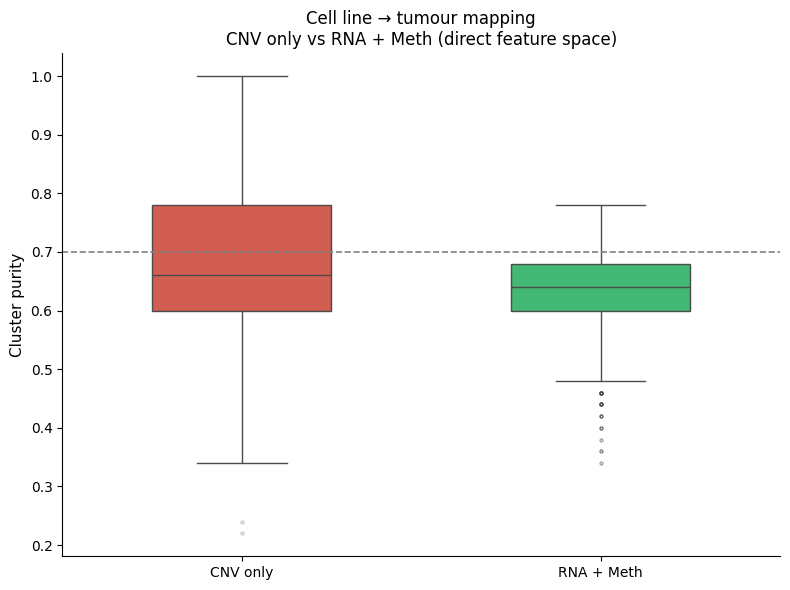

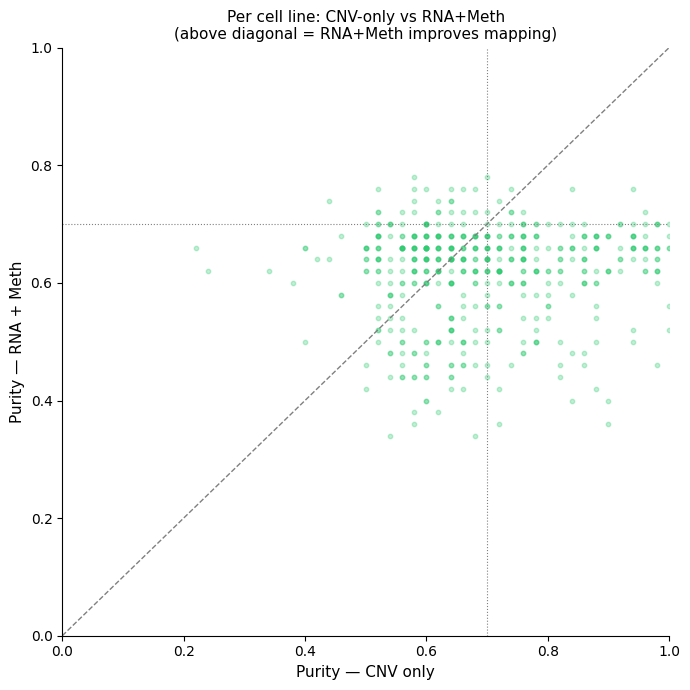

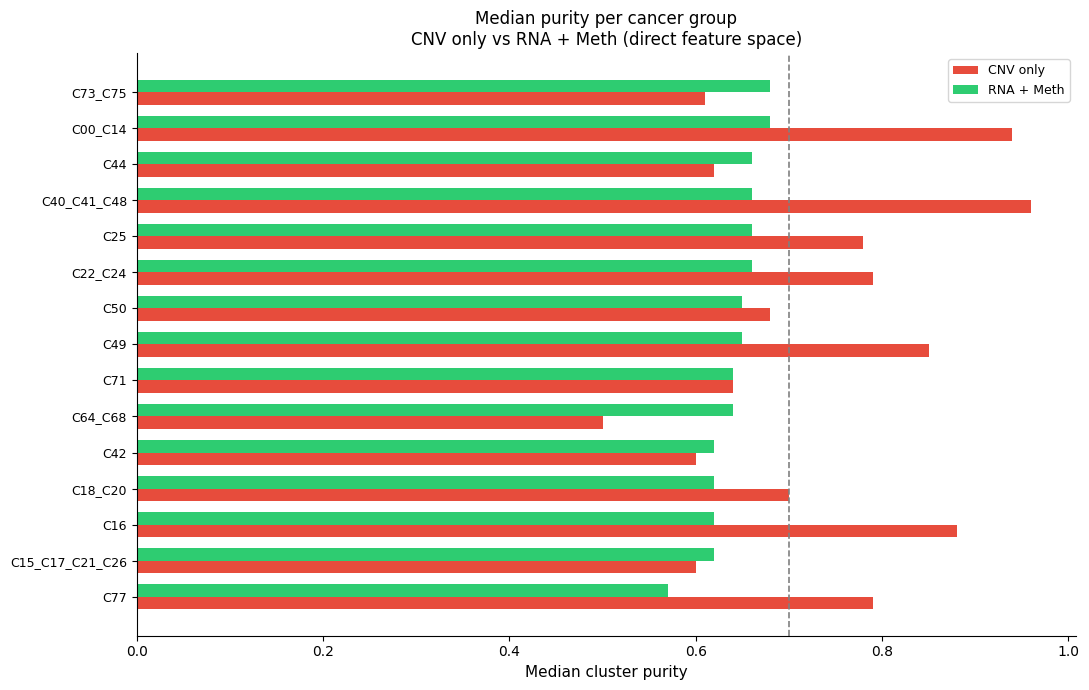

In [45]:
# ── Figures ───────────────────────────────────────────────────

# Fig 1 — Boxplot
fig, ax = plt.subplots(figsize=(8, 6))
data_plot = pd.DataFrame({
    "CNV only":  df_compare["purity_cnv"].values,
    "RNA + Meth": df_compare["purity_rna_meth"].values,
})
sns.boxplot(data=data_plot,
            palette=["#e74c3c", "#2ecc71"],
            width=0.5, ax=ax,
            flierprops=dict(marker="o", markersize=2, alpha=0.3))
ax.axhline(0.7, color="gray", linestyle="--", linewidth=1.2)
ax.set_ylabel("Cluster purity", fontsize=11)
ax.set_title("Cell line → tumour mapping\n"
             "CNV only vs RNA + Meth (direct feature space)",
             fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_direct_boxplot.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Fig 2 — Scatter per cell line
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df_compare["purity_cnv"],
           df_compare["purity_rna_meth"],
           alpha=0.3, s=10, color="#2ecc71")
ax.plot([0, 1], [0, 1], color="gray",
        linestyle="--", linewidth=1)
ax.axhline(0.7, color="gray", linestyle=":", linewidth=0.8)
ax.axvline(0.7, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("Purity — CNV only", fontsize=11)
ax.set_ylabel("Purity — RNA + Meth", fontsize=11)
ax.set_title("Per cell line: CNV-only vs RNA+Meth\n"
             "(above diagonal = RNA+Meth improves mapping)",
             fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_direct_scatter.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Fig 3 — Per group
df_compare_group = (
    df_compare
    .groupby("icdot_root")[["purity_cnv", "purity_rna_meth"]]
    .median()
    .sort_values("purity_rna_meth", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))
x     = range(len(df_compare_group))
width = 0.35
ax.barh([i - width/2 for i in x],
        df_compare_group["purity_cnv"],
        height=width, color="#e74c3c", label="CNV only")
ax.barh([i + width/2 for i in x],
        df_compare_group["purity_rna_meth"],
        height=width, color="#2ecc71", label="RNA + Meth")
ax.set_yticks(list(x))
ax.set_yticklabels(df_compare_group.index, fontsize=9)
ax.axvline(0.7, color="gray", linestyle="--", linewidth=1.2)
ax.set_xlabel("Median cluster purity", fontsize=11)
ax.set_title("Median purity per cancer group\n"
             "CNV only vs RNA + Meth (direct feature space)",
             fontsize=12)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_direct_per_group.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [46]:
# ── Build CNV + RNA + Meth combined matrix ────────────────────
print("Building CNV + RNA + Meth combined matrix...")

# Cell lines with CNV data
cl_cnv_ids = df_cl_cnv_wide.index.tolist()

# Cell lines with all three omics
cl_all_three_ids = sorted(
    set(cl_both) & set(cl_cnv_ids)
)
print(f"Cell lines with CNV + RNA + Meth : {len(cl_all_three_ids)}")

# ── Standardize CNV ───────────────────────────────────────────
# Load CNV tumour data from meta_final
print("Loading tumour CNV from meta_final...")
cnv_cols_meta = [c for c in df_meta_cols
                 if c.startswith("cnv_") and c.endswith("__dup")
                 or c.startswith("cnv_") and c.endswith("__del")]

# Actually check what CNV cols are available
cnv_cols_check = [c for c in df_meta_cols if c.startswith("cnv_")]
print(f"CNV cols in meta_final : {len(cnv_cols_check)}")
print(f"Sample : {cnv_cols_check[:5]}")

# Cell line CNV feature format: 'A1CF__dup_CNV'
# meta_final CNV format: 'cnv_A1CF__dup' or 'cnv_A1CF__dup_frac'?

Building CNV + RNA + Meth combined matrix...
Cell lines with CNV + RNA + Meth : 818
Loading tumour CNV from meta_final...
CNV cols in meta_final : 5204
Sample : ['cnv_A1CF__dup', 'cnv_ABCB1__dup', 'cnv_ABCC3__dup', 'cnv_ABI1__dup', 'cnv_ABL1__dup']


In [47]:
# ── Align CNV features between tumours and cell lines ─────────
# meta_final : 'cnv_A1CF__dup'
# cell line  : 'A1CF__dup_CNV'

# Extract gene+type from both sides
meta_cnv_genes = set(c.replace("cnv_", "") for c in cnv_cols_check)
cl_cnv_genes   = set(c.replace("_CNV", "") for c in df_cl_cnv_wide.columns)

common_cnv     = sorted(meta_cnv_genes & cl_cnv_genes)
print(f"Tumour CNV features   : {len(meta_cnv_genes)}")
print(f"Cell line CNV features: {len(cl_cnv_genes)}")
print(f"Common CNV features   : {len(common_cnv)}")

tumour_cnv_cols_sort = [f"cnv_{g}" for g in common_cnv]
cl_cnv_cols_sort     = [f"{g}_CNV" for g in common_cnv]

Tumour CNV features   : 5204
Cell line CNV features: 5188
Common CNV features   : 5188


In [48]:
# ── Load tumour CNV from meta_final ───────────────────────────
print("Loading tumour CNV (may take a few minutes)...")

df_tumours_cnv = pd.read_csv(
    META_FINAL, sep="\t", low_memory=False,
    usecols=["biosample_id"] + tumour_cnv_cols_sort
)
print(f"Tumour CNV shape : {df_tumours_cnv.shape}")

Loading tumour CNV (may take a few minutes)...
Tumour CNV shape : (9592, 5189)


In [49]:
# ── Standardize CNV ───────────────────────────────────────────
# Cell lines with CNV — align index
df_cl_cnv_aligned = df_cl_cnv_wide[cl_cnv_cols_sort].copy()

X_tumour_cnv, X_cl_cnv, valid_cnv = standardize_to_tumour(
    df_tumours_cnv,
    df_cl_cnv_aligned,
    tumour_cnv_cols_sort,
    cl_cnv_cols_sort,
    "CNV"
)

print(f"\nX_tumour_cnv shape : {X_tumour_cnv.shape}")
print(f"X_cl_cnv shape     : {X_cl_cnv.shape}")

  CNV: 5128/5188 features with non-zero std
  CNV tumour std range : [-0.843, 97.934]
  CNV cl std range     : [-0.843, 48971.918]

X_tumour_cnv shape : (9592, 5128)
X_cl_cnv shape     : (5752, 5128)


In [50]:
# ── Build CNV + RNA + Meth combined matrices ──────────────────
print("Building combined CNV + RNA + Meth matrices...")

# Tumours with all three omics
tumour_cnv_ids  = df_tumours_cnv["biosample_id"].tolist()
tumour_all_ids  = sorted(
    set(tumour_both_ids) & set(tumour_cnv_ids)
)
print(f"Tumours with CNV + RNA + Meth : {len(tumour_all_ids)}")

# Indices
cnv_t_idx = {bid: i for i, bid in enumerate(tumour_cnv_ids)}

# Cell lines with all three — use cl_all_three_ids
cl_cnv_ids_list = df_cl_cnv_wide.index.tolist()
cnv_c_idx = {bid: i for i, bid in enumerate(cl_cnv_ids_list)}

# Combined tumour matrix
X_tumour_all = np.hstack([
    X_tumour_rna[[rna_t_idx[b]  for b in tumour_all_ids]],
    X_tumour_meth[[meth_t_idx[b] for b in tumour_all_ids]],
    X_tumour_cnv[[cnv_t_idx[b]   for b in tumour_all_ids]],
])
print(f"Combined tumour matrix (CNV+RNA+Meth) : {X_tumour_all.shape}")

# Combined cell line matrix
# Only cell lines with all three omics
cl_all_ids = sorted(
    set(cl_both) &
    set(cl_cnv_ids_list)
)
print(f"Cell lines with all three omics : {len(cl_all_ids)}")

X_cl_all = np.hstack([
    X_cl_rna[[rna_idx[b]   for b in cl_all_ids]],
    X_cl_meth[[meth_idx[b]  for b in cl_all_ids]],
    X_cl_cnv[[cnv_c_idx[b]  for b in cl_all_ids]],
])
print(f"Combined cell line matrix (CNV+RNA+Meth) : {X_cl_all.shape}")

Building combined CNV + RNA + Meth matrices...
Tumours with CNV + RNA + Meth : 9545
Combined tumour matrix (CNV+RNA+Meth) : (9545, 7402)
Cell lines with all three omics : 818
Combined cell line matrix (CNV+RNA+Meth) : (818, 7402)


In [51]:
# ── kNN with CNV + RNA + Meth ─────────────────────────────────
print("Running kNN (CNV + RNA + Meth)...")

nn_all = NearestNeighbors(
    n_neighbors=K_NEIGHBORS,
    metric="euclidean", algorithm="auto"
)
nn_all.fit(X_tumour_all)
dists_all, idx_all = nn_all.kneighbors(X_cl_all)

records_all = []
for i, bid in enumerate(cl_all_ids):
    neighbour_ids = [tumour_all_ids[j] for j in idx_all[i]]

    neighbour_clusters = []
    for nid in neighbour_ids:
        if nid in tumour_cluster_map.index:
            info = tumour_cluster_map.loc[nid]
            neighbour_clusters.append(
                (info["cancer_group"], info["cluster"])
            )

    if not neighbour_clusters:
        continue

    counts   = pd.Series(neighbour_clusters).value_counts()
    dominant = counts.idxmax()
    purity   = counts.max() / len(neighbour_clusters)

    records_all.append({
        "biosample_id":           bid,
        "dominant_cluster":       int(dominant[1]),
        "dominant_cancer_group":  dominant[0],
        "cluster_purity":         float(purity),
        "n_neighbours_annotated": len(neighbour_clusters),
        "mean_distance":          float(dists_all[i].mean()),
    })

df_purity_all = pd.DataFrame(records_all)
print(f"Cell lines processed    : {len(df_purity_all)}")
print(f"Median purity CNV+RNA+Meth : "
      f"{df_purity_all['cluster_purity'].median():.3f}")

df_purity_all.to_parquet(
    INFERENCE_DIR / "purity_direct_cnv_rna_meth.parquet"
)
print("Saved: purity_direct_cnv_rna_meth.parquet")

Running kNN (CNV + RNA + Meth)...
Cell lines processed    : 818
Median purity CNV+RNA+Meth : 0.280
Saved: purity_direct_cnv_rna_meth.parquet


In [54]:
# ── Fix: PCA reduction per omic before combining ─────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Reducing each omic with PCA before combining...")

N_COMPONENTS = 20  # same as MOFA — 20 factors per omic

def pca_reduce(X_tumour, X_cl, n_components, omic_name):
    """
    Fit PCA on tumours, transform both tumours and cell lines.
    """
    n_comp = min(n_components, X_tumour.shape[1],
                 X_tumour.shape[0] - 1)
    pca = PCA(n_components=n_comp, random_state=42)
    pca.fit(X_tumour)

    X_tumour_pca = pca.transform(X_tumour)
    X_cl_pca     = pca.transform(X_cl)

    var_explained = pca.explained_variance_ratio_.sum()
    print(f"  {omic_name}: {n_comp} PCs, "
          f"variance explained = {var_explained:.3f}, "
          f"tumour shape = {X_tumour_pca.shape}, "
          f"cl shape = {X_cl_pca.shape}")

    return X_tumour_pca, X_cl_pca


# PCA per omic on tumour-aligned matrices
# RNA — tumours with both RNA+Meth, cell lines with both
t_rna_idx_both  = [rna_t_idx[b]  for b in tumour_both_ids]
t_meth_idx_both = [meth_t_idx[b] for b in tumour_both_ids]
t_cnv_idx_both  = [cnv_t_idx[b]  for b in tumour_all_ids]
cl_rna_idx_all  = [rna_idx[b]    for b in cl_all_ids]
cl_meth_idx_all = [meth_idx[b]   for b in cl_all_ids]
cl_cnv_idx_all  = [cnv_c_idx[b]  for b in cl_all_ids]

# For CNV+RNA+Meth we need tumours with all three
# Use tumour_all_ids (already computed)
t_rna_idx_all  = [rna_t_idx[b]  for b in tumour_all_ids]
t_meth_idx_all = [meth_t_idx[b] for b in tumour_all_ids]
t_cnv_idx_all  = [cnv_t_idx[b]  for b in tumour_all_ids]

X_t_rna_pca, X_cl_rna_pca   = pca_reduce(
    X_tumour_rna[t_rna_idx_all],
    X_cl_rna[cl_rna_idx_all],
    N_COMPONENTS, "RNA"
)
X_t_meth_pca, X_cl_meth_pca = pca_reduce(
    X_tumour_meth[t_meth_idx_all],
    X_cl_meth[cl_meth_idx_all],
    N_COMPONENTS, "Meth"
)
X_t_cnv_pca, X_cl_cnv_pca   = pca_reduce(
    X_tumour_cnv[t_cnv_idx_all],
    X_cl_cnv[cl_cnv_idx_all],
    N_COMPONENTS, "CNV"
)

Reducing each omic with PCA before combining...
  RNA: 20 PCs, variance explained = 0.497, tumour shape = (9545, 20), cl shape = (818, 20)
  Meth: 20 PCs, variance explained = 0.804, tumour shape = (9545, 20), cl shape = (818, 20)
  CNV: 20 PCs, variance explained = 0.247, tumour shape = (9545, 20), cl shape = (818, 20)


In [55]:
# ── Combine PCA-reduced omics ─────────────────────────────────
# Now each omic contributes equally (20 PCs each)

# CNV + RNA + Meth
X_tumour_combined_pca = np.hstack([
    X_t_cnv_pca, X_t_rna_pca, X_t_meth_pca
])
X_cl_combined_pca = np.hstack([
    X_cl_cnv_pca, X_cl_rna_pca, X_cl_meth_pca
])
print(f"Combined tumour (PCA) : {X_tumour_combined_pca.shape}")
print(f"Combined cl (PCA)     : {X_cl_combined_pca.shape}")

# RNA + Meth only (for same cell lines)
X_tumour_rna_meth_pca = np.hstack([X_t_rna_pca, X_t_meth_pca])
X_cl_rna_meth_pca     = np.hstack([X_cl_rna_pca, X_cl_meth_pca])

# CNV only (for same cell lines)
X_tumour_cnv_only_pca = X_t_cnv_pca
X_cl_cnv_only_pca     = X_cl_cnv_pca

Combined tumour (PCA) : (9545, 60)
Combined cl (PCA)     : (818, 60)


In [56]:
# ── kNN for all three approaches on same cell lines ───────────
def run_knn_pca(X_tumour, X_cl, cl_ids, tumour_ids,
                tumour_cluster_map, k, label):
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(X_tumour)
    dists, idx = nn.kneighbors(X_cl)

    records = []
    for i, bid in enumerate(cl_ids):
        neighbour_ids = [tumour_ids[j] for j in idx[i]]
        neighbour_clusters = []
        for nid in neighbour_ids:
            if nid in tumour_cluster_map.index:
                info = tumour_cluster_map.loc[nid]
                neighbour_clusters.append(
                    (info["cancer_group"], info["cluster"])
                )
        if not neighbour_clusters:
            continue

        counts   = pd.Series(neighbour_clusters).value_counts()
        dominant = counts.idxmax()
        purity   = counts.max() / len(neighbour_clusters)
        records.append({
            "biosample_id":  bid,
            "cluster_purity": float(purity),
        })

    df = pd.DataFrame(records)
    print(f"  {label}: {len(df)} cell lines, "
          f"median purity = {df['cluster_purity'].median():.3f}")
    return df


print("Running kNN with PCA-reduced features...")
df_p_cnv      = run_knn_pca(
    X_tumour_cnv_only_pca, X_cl_cnv_only_pca,
    cl_all_ids, tumour_all_ids,
    tumour_cluster_map, K_NEIGHBORS, "CNV only (PCA)"
)
df_p_rna_meth = run_knn_pca(
    X_tumour_rna_meth_pca, X_cl_rna_meth_pca,
    cl_all_ids, tumour_all_ids,
    tumour_cluster_map, K_NEIGHBORS, "RNA + Meth (PCA)"
)
df_p_all      = run_knn_pca(
    X_tumour_combined_pca, X_cl_combined_pca,
    cl_all_ids, tumour_all_ids,
    tumour_cluster_map, K_NEIGHBORS, "CNV + RNA + Meth (PCA)"
)

Running kNN with PCA-reduced features...
  CNV only (PCA): 818 cell lines, median purity = 0.220
  RNA + Meth (PCA): 818 cell lines, median purity = 0.680
  CNV + RNA + Meth (PCA): 818 cell lines, median purity = 0.340


In [57]:
# ── Final comparison ──────────────────────────────────────────
df_final_pca = (
    df_cnv_pur
    .merge(df_p_cnv.rename(
        columns={"cluster_purity": "purity_cnv_pca"}),
        on="biosample_id", how="inner")
    .merge(df_p_rna_meth.rename(
        columns={"cluster_purity": "purity_rna_meth_pca"}),
        on="biosample_id", how="inner")
    .merge(df_p_all.rename(
        columns={"cluster_purity": "purity_all_pca"}),
        on="biosample_id", how="inner")
)

print(f"\nCell lines in comparison : {len(df_final_pca)}")
print(f"\nMedian purity :")
print(f"  CNV only (original) : "
      f"{df_final_pca['purity_cnv'].median():.3f}")
print(f"  CNV only (PCA)      : "
      f"{df_final_pca['purity_cnv_pca'].median():.3f}")
print(f"  RNA + Meth (PCA)    : "
      f"{df_final_pca['purity_rna_meth_pca'].median():.3f}")
print(f"  CNV+RNA+Meth (PCA)  : "
      f"{df_final_pca['purity_all_pca'].median():.3f}")

stat, p = wilcoxon(df_final_pca["purity_cnv"],
                   df_final_pca["purity_all_pca"])
print(f"\nWilcoxon CNV vs CNV+RNA+Meth (PCA) : p = {p:.2e}")

# Per group
group_pca = (
    df_final_pca
    .groupby("icdot_root")
    .agg(
        n                  = ("biosample_id",       "count"),
        purity_cnv         = ("purity_cnv",          "median"),
        purity_rna_meth    = ("purity_rna_meth_pca", "median"),
        purity_all         = ("purity_all_pca",       "median"),
    )
    .reset_index()
)
group_pca["delta"] = (
    group_pca["purity_all"] - group_pca["purity_cnv"]
)
group_pca = group_pca.sort_values("delta", ascending=False)
print(f"\nPer group delta (CNV+RNA+Meth vs CNV only) :")
print(group_pca.to_string(index=False))

df_final_pca.to_csv(
    INFERENCE_DIR / "purity_final_pca.tsv",
    sep="\t", index=False
)
print("\nSaved: purity_final_pca.tsv")


Cell lines in comparison : 521

Median purity :
  CNV only (original) : 0.660
  CNV only (PCA)      : 0.220
  RNA + Meth (PCA)    : 0.660
  CNV+RNA+Meth (PCA)  : 0.320

Wilcoxon CNV vs CNV+RNA+Meth (PCA) : p = 3.51e-84

Per group delta (CNV+RNA+Meth vs CNV only) :
     icdot_root   n  purity_cnv  purity_rna_meth  purity_all     delta
        C73_C75  10        0.61             0.72    0.490000 -0.120000
        C64_C68  23        0.50             0.66    0.300000 -0.200000
            C44  55        0.62             0.72    0.380000 -0.240000
            C42 112        0.60             0.66    0.340000 -0.260000
C15_C17_C21_C26  23        0.60             0.62    0.285714 -0.314286
            C71  45        0.64             0.70    0.300000 -0.340000
        C18_C20  53        0.70             0.66    0.340000 -0.360000
            C50  50        0.68             0.68    0.310000 -0.370000
            C77  32        0.79             0.58    0.320000 -0.470000
        C22_C24  24     

In [58]:
# Which groups does RNA+Meth beat CNV?
group_pca["delta_rna_vs_cnv"] = (
    group_pca["purity_rna_meth"] - group_pca["purity_cnv"]
)
improved = group_pca[group_pca["delta_rna_vs_cnv"] > 0].sort_values(
    "delta_rna_vs_cnv", ascending=False
)
print("Groups where RNA+Meth > CNV :")
print(improved[["icdot_root", "n", "purity_cnv",
                 "purity_rna_meth",
                 "delta_rna_vs_cnv"]].to_string(index=False))

Groups where RNA+Meth > CNV :
     icdot_root   n  purity_cnv  purity_rna_meth  delta_rna_vs_cnv
        C64_C68  23        0.50             0.66              0.16
        C73_C75  10        0.61             0.72              0.11
            C44  55        0.62             0.72              0.10
            C42 112        0.60             0.66              0.06
            C71  45        0.64             0.70              0.06
C15_C17_C21_C26  23        0.60             0.62              0.02


In [59]:
# ── Fair comparison: CNV(PCA) vs CNV+RNA+Meth(PCA) ───────────
# Both use the same PCA reduction approach
# so the comparison is methodologically consistent

print("Fair comparison — all omics reduced with global PCA...")
print(f"\nMedian purity (same 521 cell lines, same method) :")
print(f"  CNV only (global PCA, 20 PCs)      : "
      f"{df_final_pca['purity_cnv_pca'].median():.3f}")
print(f"  RNA + Meth (global PCA, 20+20 PCs) : "
      f"{df_final_pca['purity_rna_meth_pca'].median():.3f}")
print(f"  CNV+RNA+Meth (global PCA, 60 PCs)  : "
      f"{df_final_pca['purity_all_pca'].median():.3f}")

# Per group — where does CNV+RNA+Meth beat CNV alone?
group_pca["delta_all_vs_cnv"] = (
    group_pca["purity_all"] - group_pca["purity_cnv_pca"]
)
group_pca = group_pca.sort_values("delta_all_vs_cnv", ascending=False)

print(f"\nPer group — CNV+RNA+Meth vs CNV only (both PCA) :")
print(group_pca[["icdot_root", "n", "purity_cnv",
                  "purity_rna_meth", "purity_all",
                  "delta_all_vs_cnv"]].to_string(index=False))

improved = group_pca[group_pca["delta_all_vs_cnv"] > 0]
print(f"\nGroups where CNV+RNA+Meth BEATS CNV (delta > 0) :")
print(improved[["icdot_root", "n",
                 "purity_cnv", "purity_all",
                 "delta_all_vs_cnv"]].to_string(index=False))

Fair comparison — all omics reduced with global PCA...

Median purity (same 521 cell lines, same method) :
  CNV only (global PCA, 20 PCs)      : 0.220
  RNA + Meth (global PCA, 20+20 PCs) : 0.660
  CNV+RNA+Meth (global PCA, 60 PCs)  : 0.320


KeyError: 'purity_cnv_pca'

In [62]:
# ── Recompute group_pca with correct column names ─────────────
group_pca = (
    df_final_pca
    .groupby("icdot_root")
    .agg(
        n                   = ("biosample_id",        "count"),
        purity_cnv_orig     = ("purity_cnv",           "median"),
        purity_cnv_pca      = ("purity_cnv_pca",       "median"),
        purity_rna_meth_pca = ("purity_rna_meth_pca",  "median"),
        purity_all_pca      = ("purity_all_pca",        "median"),
    )
    .reset_index()
)

# Delta: CNV+RNA+Meth(PCA) vs CNV(PCA) — fair comparison
group_pca["delta_all_vs_cnv_pca"] = (
    group_pca["purity_all_pca"] - group_pca["purity_cnv_pca"]
)

# Delta: CNV+RNA+Meth(PCA) vs CNV original — practical comparison
group_pca["delta_all_vs_cnv_orig"] = (
    group_pca["purity_all_pca"] - group_pca["purity_cnv_orig"]
)

group_pca = group_pca.sort_values(
    "delta_all_vs_cnv_pca", ascending=False
)

print("Fair comparison — CNV+RNA+Meth(PCA) vs CNV(PCA) :")
print(f"\nGlobal medians :")
print(f"  CNV original        : "
      f"{df_final_pca['purity_cnv'].median():.3f}")
print(f"  CNV PCA             : "
      f"{df_final_pca['purity_cnv_pca'].median():.3f}")
print(f"  RNA+Meth PCA        : "
      f"{df_final_pca['purity_rna_meth_pca'].median():.3f}")
print(f"  CNV+RNA+Meth PCA    : "
      f"{df_final_pca['purity_all_pca'].median():.3f}")

print(f"\nPer group :")
print(group_pca[[
    "icdot_root", "n",
    "purity_cnv_pca", "purity_rna_meth_pca", "purity_all_pca",
    "delta_all_vs_cnv_pca"
]].to_string(index=False))

print(f"\nGroups where CNV+RNA+Meth BEATS CNV (fair, delta > 0) :")
improved = group_pca[group_pca["delta_all_vs_cnv_pca"] > 0]
print(improved[[
    "icdot_root", "n",
    "purity_cnv_pca", "purity_all_pca",
    "delta_all_vs_cnv_pca"
]].to_string(index=False))

Fair comparison — CNV+RNA+Meth(PCA) vs CNV(PCA) :

Global medians :
  CNV original        : 0.660
  CNV PCA             : 0.220
  RNA+Meth PCA        : 0.660
  CNV+RNA+Meth PCA    : 0.320

Per group :
     icdot_root   n  purity_cnv_pca  purity_rna_meth_pca  purity_all_pca  delta_all_vs_cnv_pca
        C73_C75  10            0.20                 0.72        0.490000              0.290000
            C44  55            0.20                 0.72        0.380000              0.180000
            C42 112            0.22                 0.66        0.340000              0.120000
    C40_C41_C48  17            0.24                 0.72        0.360000              0.120000
            C71  45            0.18                 0.70        0.300000              0.120000
        C18_C20  53            0.24                 0.66        0.340000              0.100000
            C77  32            0.22                 0.58        0.320000              0.100000
        C22_C24  24            0.22    

In [63]:
# ── Correct approach: per-group kNN with CNV + RNA + Meth ─────
# For each cancer group:
#   1. Get tumour CNV PCs (already computed in inference notebook)
#   2. Add tumour RNA and Meth features (standardized)
#   3. Concatenate CNV PCs + RNA features + Meth features
#   4. kNN in this combined space
#   5. Compare purity with CNV-only kNN

from pathlib import Path
import joblib, json

FINAL_SPACE_DIR  = CNV_ONLY_BASE / "final_space"
FINAL_MANIFEST   = FINAL_SPACE_DIR / "manifest_final.tsv"
MODELS_DIR       = CNV_ONLY_BASE / "models_stage2A"
MODELS_MANIFEST  = MODELS_DIR / "models_manifest.tsv"

manifest_final  = pd.read_csv(FINAL_MANIFEST,   sep="\t")
manifest_models = pd.read_csv(MODELS_MANIFEST,  sep="\t")

print(f"Final space manifest : {manifest_final.shape}")
print(manifest_final.head())
print(f"\nModels manifest : {manifest_models.shape}")
print(manifest_models.columns.tolist())

Final space manifest : (22, 3)
        icdot_root                     final_pcs_file final_choice
0          C00_C14          C00_C14_PCs_final.parquet      stage2A
1  C15_C17_C21_C26  C15_C17_C21_C26_PCs_final.parquet      stage2A
2              C16              C16_PCs_final.parquet      stage2A
3          C18_C20          C18_C20_PCs_final.parquet      stage2A
4          C22_C24          C22_C24_PCs_final.parquet      stage2A

Models manifest : (22, 8)
['icdot_root', 'scaler_path', 'pca_path', 'feature_columns_path', 'model_meta_path', 'n_samples_fit', 'n_features_fit', 'n_pcs_fit']


In [64]:
# ── Build bridge: icdot_root → biosample_ids ──────────────────
# We need to map icdot_root to biosample_ids for tumours
# so we can extract their RNA and Meth features

# Load meta_final biosample_id + cancer_group + icdot
df_meta_ids = pd.read_csv(
    META_FINAL, sep="\t", low_memory=False,
    usecols=["biosample_id", "cancer_group"]
)
print(f"meta_final ids : {df_meta_ids.shape}")
print(df_meta_ids.head(3))

meta_final ids : (9592, 2)
     biosample_id                   cancer_group
0  pgxbs-kftvho6e  Esophagus/Intestine (C15-C26)
1  pgxbs-kftvi3kp      Bone/SoftTissue (C40-C48)
2  pgxbs-kftvhsbh          Gynecologic (C51-C58)


In [65]:
# ── Per-group CNV + RNA + Meth inference ──────────────────────

# Build biosample_id → cancer_group lookup
bid_to_group = df_meta_ids.set_index("biosample_id")["cancer_group"].to_dict()

# Build icdot_root → cancer_group name lookup
# (icdot_root 'C15_C17_C21_C26' → 'Esophagus/Intestine (C15-C26)')
icdot_to_cancer_group = {}
for root in manifest_final["icdot_root"]:
    # Find a tumour in this root's PC file to get cancer_group name
    pc_file = FINAL_SPACE_DIR / \
              manifest_final.loc[
                  manifest_final["icdot_root"] == root,
                  "final_pcs_file"
              ].values[0]
    df_pc = pd.read_parquet(pc_file).reset_index()
    id_col = "biosample_id" if "biosample_id" in df_pc.columns \
             else df_pc.columns[0]
    sample_bid = df_pc[id_col].iloc[0]
    if sample_bid in bid_to_group:
        icdot_to_cancer_group[root] = bid_to_group[sample_bid]

print("icdot_root → cancer_group mapping :")
for k, v in list(icdot_to_cancer_group.items())[:5]:
    print(f"  {k} → {v}")

icdot_root → cancer_group mapping :
  C00_C14 → Head & Neck (C00-C14)
  C15_C17_C21_C26 → Esophagus/Intestine (C15-C26)
  C16 → C16
  C18_C20 → Colorectal (C18-C20)
  C22_C24 → Liver/Biliary (C22-C24)


In [66]:
# ── Build tumour RNA + Meth lookup ────────────────────────────
# Index tumour RNA and Meth matrices by biosample_id
# so we can quickly extract features for any group

# Tumour RNA — rows indexed by biosample_id
tumour_rna_bids = df_tumours_rna["biosample_id"].tolist()
rna_t_bid_idx   = {bid: i for i, bid in enumerate(tumour_rna_bids)}

# Tumour Meth — rows indexed by biosample_id
tumour_meth_bids = df_tumours_meth["biosample_id"].tolist()
meth_t_bid_idx   = {bid: i for i, bid in enumerate(tumour_meth_bids)}

# Cell line bridge: biosample_id → ModelID
cl_bid_to_model = (
    df_bridge[df_bridge["ModelID"].notna()]
    .drop_duplicates("biosample_id")
    .set_index("biosample_id")["ModelID"]
    .to_dict()
)

# Cell line RNA/Meth indexed by biosample_id
cl_rna_bids  = df_rna_indexed.index.tolist()
cl_meth_bids = df_meth_indexed.index.tolist()
cl_rna_bid_idx  = {bid: i for i, bid in enumerate(cl_rna_bids)}
cl_meth_bid_idx = {bid: i for i, bid in enumerate(cl_meth_bids)}

print(f"Tumour RNA  indexed : {len(rna_t_bid_idx)}")
print(f"Tumour Meth indexed : {len(meth_t_bid_idx)}")
print(f"Cell line RNA  indexed : {len(cl_rna_bid_idx)}")
print(f"Cell line Meth indexed : {len(cl_meth_bid_idx)}")

Tumour RNA  indexed : 9545
Tumour Meth indexed : 9545
Cell line RNA  indexed : 1085
Cell line Meth indexed : 818


In [67]:
# ── Per-group inference loop ───────────────────────────────────
from sklearn.preprocessing import normalize

N_PCS_KNN     = 20
FEATURES_UNFILTERED_DIR = Path(
    "/Users/bgadmin/Downloads/features_unfiltered"
)

results_multiomics = []

for _, mrow in manifest_final.iterrows():
    root = mrow["icdot_root"]

    # ── Load tumour CNV PCs ───────────────────────────────────
    pc_file  = FINAL_SPACE_DIR / mrow["final_pcs_file"]
    df_t_pc  = pd.read_parquet(pc_file).reset_index()
    id_col   = "biosample_id" if "biosample_id" in df_t_pc.columns \
               else df_t_pc.columns[0]
    tumour_bids = df_t_pc[id_col].astype(str).tolist()

    # Rename PC columns
    pc_cols = [c for c in df_t_pc.columns if c.startswith("PC")]
    rename  = {c: f"PC_{c[2:]}" if not c.startswith("PC_") else c
               for c in pc_cols}
    df_t_pc = df_t_pc.rename(columns=rename)
    used_pcs = [f"PC_{i+1}" for i in range(N_PCS_KNN)
                if f"PC_{i+1}" in df_t_pc.columns]

    X_t_cnv = df_t_pc[used_pcs].values.astype(np.float32)

    if len(tumour_bids) < K_NEIGHBORS:
        print(f"  [{root}] too few tumours ({len(tumour_bids)}) → skip")
        continue

    # ── Get tumour RNA features for this group ────────────────
    t_rna_avail  = [b for b in tumour_bids if b in rna_t_bid_idx]
    t_meth_avail = [b for b in tumour_bids if b in meth_t_bid_idx]
    t_both       = sorted(set(t_rna_avail) & set(t_meth_avail))

    if len(t_both) < K_NEIGHBORS:
        print(f"  [{root}] too few tumours with RNA+Meth "
              f"({len(t_both)}) → skip")
        continue

    # Tumour indices for this group
    t_both_order = [tumour_bids.index(b) for b in t_both]
    X_t_cnv_sub  = X_t_cnv[t_both_order]

    X_t_rna  = X_tumour_rna[[rna_t_bid_idx[b]  for b in t_both]]
    X_t_meth = X_tumour_meth[[meth_t_bid_idx[b] for b in t_both]]

    # ── Get cell line CNV PCs for this group ──────────────────
    cl_purity_root = df_cnv_purity[
        df_cnv_purity["icdot_root"] == root
    ].copy()

    if cl_purity_root.empty:
        print(f"  [{root}] no cell lines → skip")
        continue

    cl_bids_root = cl_purity_root["cl_biosample_id"].tolist()

    # Project cell lines into CNV PC space (reuse existing results)
    # Load projected cell line PCs
    cl_proj_file = INFERENCE_DIR.parent / "inference" / \
                   "celllines_pcs_projected.parquet"
    df_cl_proj   = pd.read_parquet(cl_proj_file)
    df_cl_proj_root = df_cl_proj[
        (df_cl_proj["icdot_root"] == root) &
        (df_cl_proj["biosample_id"].isin(cl_bids_root))
    ].copy()

    if df_cl_proj_root.empty:
        print(f"  [{root}] no projected cell lines → skip")
        continue

    cl_bids_proj = df_cl_proj_root["biosample_id"].tolist()
    pc_cols_cl   = [f"PC_{i+1}" for i in range(N_PCS_KNN)
                    if f"PC_{i+1}" in df_cl_proj_root.columns]
    X_cl_cnv     = df_cl_proj_root[pc_cols_cl].values.astype(np.float32)

    # ── Get cell line RNA + Meth for this group ───────────────
    cl_with_both = [b for b in cl_bids_proj
                    if b in cl_rna_bid_idx
                    and b in cl_meth_bid_idx]

    if not cl_with_both:
        print(f"  [{root}] no cell lines with RNA+Meth → skip")
        continue

    cl_both_order = [cl_bids_proj.index(b) for b in cl_with_both]
    X_cl_cnv_sub  = X_cl_cnv[cl_both_order]
    X_cl_rna_sub  = X_cl_rna[[cl_rna_bid_idx[b]
                                for b in cl_with_both]]
    X_cl_meth_sub = X_cl_meth[[cl_meth_bid_idx[b]
                                for b in cl_with_both]]

    # ── Combine CNV PCs + RNA + Meth ─────────────────────────
    X_t_combined  = np.hstack([X_t_cnv_sub,  X_t_rna,  X_t_meth])
    X_cl_combined = np.hstack([X_cl_cnv_sub, X_cl_rna_sub,
                                X_cl_meth_sub])

    # ── kNN ───────────────────────────────────────────────────
    nn = NearestNeighbors(
        n_neighbors=K_NEIGHBORS,
        metric="euclidean", algorithm="auto"
    )
    nn.fit(X_t_combined)
    dists, idx = nn.kneighbors(X_cl_combined)

    # ── Purity ────────────────────────────────────────────────
    for i, bid in enumerate(cl_with_both):
        neighbour_bids = [t_both[j] for j in idx[i]]
        neighbour_clusters = []
        for nid in neighbour_bids:
            if nid in tumour_cluster_map.index:
                info = tumour_cluster_map.loc[nid]
                neighbour_clusters.append(
                    (info["cancer_group"], info["cluster"])
                )
        if not neighbour_clusters:
            continue

        counts   = pd.Series(neighbour_clusters).value_counts()
        dominant = counts.idxmax()
        purity   = counts.max() / len(neighbour_clusters)

        results_multiomics.append({
            "biosample_id":    bid,
            "icdot_root":      root,
            "cluster_purity":  float(purity),
            "dominant_cluster": int(dominant[1]),
            "n_tumours_with_rna_meth": len(t_both),
            "n_cl_with_rna_meth":      len(cl_with_both),
        })

    print(f"  [{root}] {len(cl_with_both)} cell lines, "
          f"{len(t_both)} tumours with RNA+Meth → done")


df_purity_combined = pd.DataFrame(results_multiomics)
print(f"\nTotal : {len(df_purity_combined)} cell lines processed")
print(f"Median purity CNV+RNA+Meth (per-group) : "
      f"{df_purity_combined['cluster_purity'].median():.3f}")

df_purity_combined.to_parquet(
    INFERENCE_DIR / "purity_pergroup_cnv_rna_meth.parquet"
)
print("Saved: purity_pergroup_cnv_rna_meth.parquet")

  [C00_C14] 1 cell lines, 379 tumours with RNA+Meth → done
  [C15_C17_C21_C26] 23 cell lines, 193 tumours with RNA+Meth → done
  [C16] 33 cell lines, 379 tumours with RNA+Meth → done
  [C18_C20] 53 cell lines, 565 tumours with RNA+Meth → done
  [C22_C24] 24 cell lines, 398 tumours with RNA+Meth → done
  [C25] 35 cell lines, 165 tumours with RNA+Meth → done
  [C30_C39] no cell lines with RNA+Meth → skip
  [C40_C41_C48] 17 cell lines, 113 tumours with RNA+Meth → done
  [C42] 112 cell lines, 60 tumours with RNA+Meth → done
  [C44] 55 cell lines, 149 tumours with RNA+Meth → done
  [C47] too few tumours (1) → skip
  [C49] 8 cell lines, 196 tumours with RNA+Meth → done
  [C50] 50 cell lines, 969 tumours with RNA+Meth → done
  [C51_C58] no cell lines with RNA+Meth → skip
  [C60_C63] no cell lines → skip
  [C64_C68] 23 cell lines, 1009 tumours with RNA+Meth → done
  [C69_C70_C72] no cell lines with RNA+Meth → skip
  [C71] 45 cell lines, 737 tumours with RNA+Meth → done
  [C73_C75] 10 cell line

In [68]:
# ── Final fair comparison ─────────────────────────────────────
df_final_fair = (
    df_cnv_pur
    .merge(
        df_purity_combined[["biosample_id", "cluster_purity"]]
        .rename(columns={"cluster_purity": "purity_cnv_rna_meth"}),
        on="biosample_id", how="inner"
    )
)

print(f"Cell lines in comparison : {len(df_final_fair)}")
print(f"\nMedian purity :")
print(f"  CNV only         : {df_final_fair['purity_cnv'].median():.3f}")
print(f"  CNV+RNA+Meth     : "
      f"{df_final_fair['purity_cnv_rna_meth'].median():.3f}")

stat, p = wilcoxon(
    df_final_fair["purity_cnv"],
    df_final_fair["purity_cnv_rna_meth"]
)
print(f"\nWilcoxon CNV vs CNV+RNA+Meth : p = {p:.2e}")

# Per group
group_fair = (
    df_final_fair
    .groupby("icdot_root")
    .agg(
        n                  = ("biosample_id",        "count"),
        purity_cnv         = ("purity_cnv",           "median"),
        purity_cnv_rna_meth = ("purity_cnv_rna_meth", "median"),
    )
    .reset_index()
)
group_fair["delta"] = (
    group_fair["purity_cnv_rna_meth"] - group_fair["purity_cnv"]
)
group_fair = group_fair.sort_values("delta", ascending=False)

print(f"\nPer group — CNV+RNA+Meth vs CNV only :")
print(group_fair.to_string(index=False))

improved = group_fair[group_fair["delta"] > 0]
print(f"\nGroups where CNV+RNA+Meth BEATS CNV (delta > 0) :")
print(improved.to_string(index=False))

df_final_fair.to_csv(
    INFERENCE_DIR / "purity_final_fair_comparison.tsv",
    sep="\t", index=False
)
print("\nSaved: purity_final_fair_comparison.tsv")

Cell lines in comparison : 521

Median purity :
  CNV only         : 0.660
  CNV+RNA+Meth     : 0.860

Wilcoxon CNV vs CNV+RNA+Meth : p = 1.74e-37

Per group — CNV+RNA+Meth vs CNV only :
     icdot_root   n  purity_cnv  purity_cnv_rna_meth  delta
            C42 112        0.60                 1.00   0.40
        C73_C75  10        0.61                 0.98   0.37
        C18_C20  53        0.70                 0.98   0.28
            C71  45        0.64                 0.86   0.22
            C50  50        0.68                 0.82   0.14
            C77  32        0.79                 0.84   0.05
            C44  55        0.62                 0.66   0.04
            C16  33        0.88                 0.88   0.00
        C00_C14   1        0.94                 0.92  -0.02
        C64_C68  23        0.50                 0.48  -0.02
    C40_C41_C48  17        0.96                 0.92  -0.04
            C25  35        0.78                 0.74  -0.04
C15_C17_C21_C26  23        0.60  

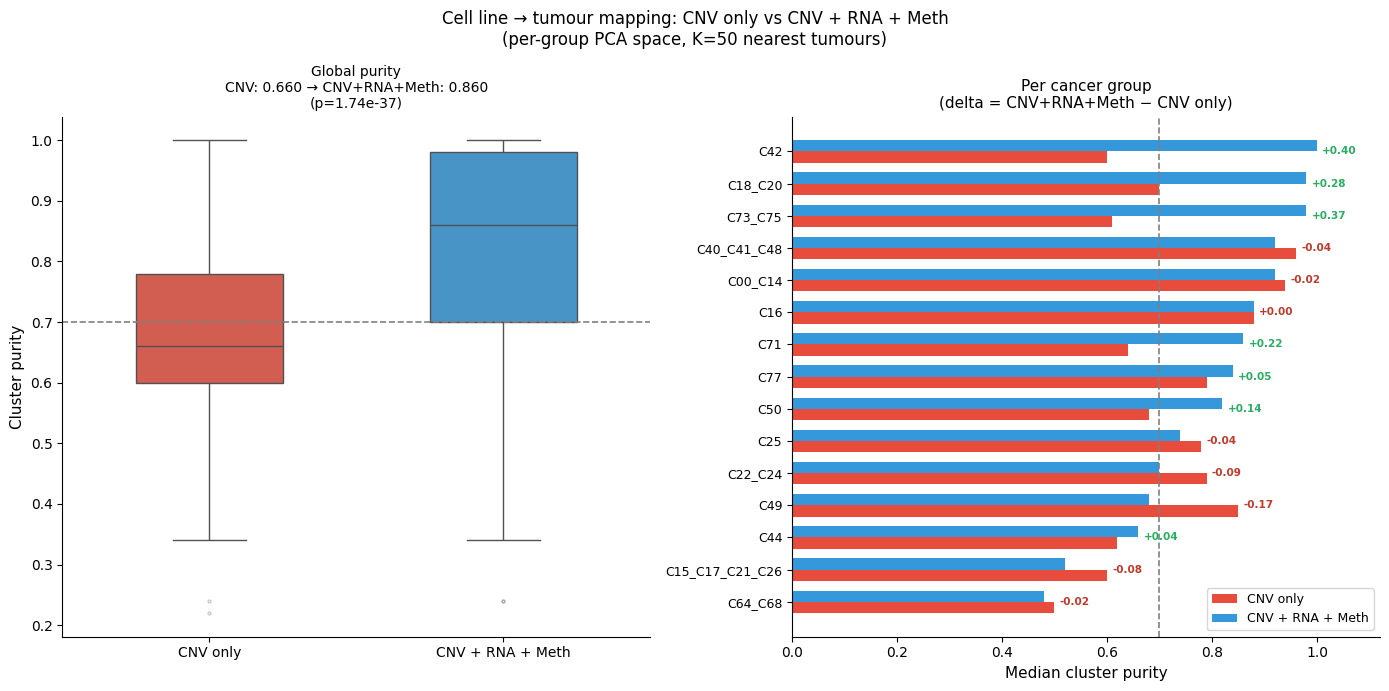

Saved: fig_final_fair_comparison.png


In [69]:
# ── Final figure ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ── Left: boxplot global ──────────────────────────────────────
data_box = pd.DataFrame({
    "CNV only":         df_final_fair["purity_cnv"].values,
    "CNV + RNA + Meth": df_final_fair["purity_cnv_rna_meth"].values,
})
sns.boxplot(data=data_box,
            palette=["#e74c3c", "#3498db"],
            width=0.5, ax=axes[0],
            flierprops=dict(marker="o", markersize=2, alpha=0.3))
axes[0].axhline(0.7, color="gray", linestyle="--", linewidth=1.2)
axes[0].set_ylabel("Cluster purity", fontsize=11)
axes[0].set_title(
    f"Global purity\n"
    f"CNV: {df_final_fair['purity_cnv'].median():.3f} → "
    f"CNV+RNA+Meth: {df_final_fair['purity_cnv_rna_meth'].median():.3f}"
    f"\n(p={1.74e-37:.2e})",
    fontsize=10
)
sns.despine(ax=axes[0])

# ── Right: per group barplot with delta annotation ────────────
gp = group_fair.sort_values("purity_cnv_rna_meth", ascending=True)
x  = range(len(gp))
w  = 0.35

bars_cnv = axes[1].barh(
    [i - w/2 for i in x], gp["purity_cnv"],
    height=w, color="#e74c3c", label="CNV only"
)
bars_all = axes[1].barh(
    [i + w/2 for i in x], gp["purity_cnv_rna_meth"],
    height=w, color="#3498db", label="CNV + RNA + Meth"
)

# Annotate delta
for i, (_, row) in enumerate(gp.iterrows()):
    delta = row["delta"]
    color = "#27ae60" if delta > 0 else "#c0392b"
    sign  = "+" if delta >= 0 else ""
    axes[1].text(
        max(row["purity_cnv"], row["purity_cnv_rna_meth"]) + 0.01,
        i,
        f"{sign}{delta:.2f}",
        va="center", fontsize=7.5,
        color=color, fontweight="bold"
    )

axes[1].set_yticks(list(x))
axes[1].set_yticklabels(gp["icdot_root"], fontsize=9)
axes[1].axvline(0.7, color="gray", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Median cluster purity", fontsize=11)
axes[1].set_title("Per cancer group\n(delta = CNV+RNA+Meth − CNV only)",
                  fontsize=11)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1.12)
sns.despine(ax=axes[1])

plt.suptitle(
    "Cell line → tumour mapping: CNV only vs CNV + RNA + Meth\n"
    "(per-group PCA space, K=50 nearest tumours)",
    fontsize=12
)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_final_fair_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_final_fair_comparison.png")